# Проект: Исследование бизнес-показателей маркетплейса

## Введение

### Цели и задачи проекта
**Цель:** Провести анализ данных маркетплейса, выявить прибыльные каналы и категории товаров.

**Задачи:**
- Первичный анализ и сбор данных.
- Обзор ключевых метрик.
- Оценка метрик монетизации и юнит-экономики.
- Поиск инсайтов и точек роста. Сегментация и формулирование гипотез.
- Подготовка эксперимента и подведение его итогов.

**Описание данных:**

#### Таблица Users:
- user_id - уникальный идентификатор пользователя;
- registration_date	- дата регистрации пользователя;
- age - возраст пользователя;
- gender - пол;
- region - регион;
- acq_channel - канал привлечения;
- buyer_segment - сегмент покупателя;
- cohort_week - неделя привлечения;
- cohort_month - месяц привлечения.

#### Таблица Events:
- event_id - уникальный идентификатор события;
- user_id - идентификатор пользователя;
- event_date - дата события;
- event_type - тип события;
- os - операционная система;
- device - тип устройства;
- product_name - наименование товара, к которому относится событие (если применимо);
- event_week - неделя события;
- event_month - месяц события.

#### Таблица Orders:
- order_id - уникальный идентификатор заказа;
- user_id - идентификатор пользователя, который сделал заказ;
- order_date - дата и время оформления заказа;
- product_name - наименование товара;
- quantity - количество единиц товара в заказе;
- unit_price- цена за одну единицу товара;
- total_price - итоговая сумма заказа;
- category_name - наименование категории товара;
- order_week - неделя заказа;
- order_month - месяц заказа.

#### Таблица Campaign_costs:
- acq_channel - канал привлечения;
- spend_month - месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи);
- budget - маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.

#### Описание событий:
- page_view - открытие любой страницы сайта или приложения пользователем;
- product_view - просмотр страницы конкретного товара;
- product_click - клик по товару (например, из списка товаров или на баннере);
- add_to_cart - добавление товара в корзину;
- remove_from_cart - удаление товара из корзины;
- search - выполнение поиска по сайту или приложению;
- filter_apply - применение фильтра (например, по цене, бренду, категории);
- checkout_start - начало оформления заказа (переход к оформлению корзины);
- checkout_complete - завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты);
- user_login - вход пользователя в личный кабинет или аккаунт;
- user_logout - выход пользователя из аккаунта;
- wishlist_add - добавление товара в список желаемого (wishlist);
- category_view - просмотр страницы категории товаров;
- banner_click - клик по рекламному баннеру на сайте или в приложении;
- promo_view - просмотр промо-акции или специального предложения.       

#### Выручка маркетплейса = 5% от total_price

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>

    
💡 Здорово, что есть описание данных, но для читателя было бы полезно увидеть:
    
- цель анализа, вводные данные и этапы проекта;
- иерархию метрик или дерево ключевых показателей — что считаем главным для «здоровья» продукта: в первую очередь retention и активность, затем монетизация, после этого — маркетинговая эффективность;
- приоритизацию анализа — какие метрики критически важны для принятия стратегических решений, а какие выступают вспомогательными индикаторами;
- краткую легенду основных терминов (CAC, LTV, ROI, retention и т. д.) для лучшего понимания бизнес-заказчиками.

Это поможет сфокусировать внимание на самых важных инсайтах.


### 1. Предобработка данных

In [1]:
#импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats 
from scipy.stats import ttest_ind, shapiro, levene
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter

In [2]:
pa_marketplace_orders = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_orders.csv')
pa_marketplace_campaign_costs = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_campaign_costs.csv')
pa_marketplace_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_users.csv')
pa_marketplace_events = pd.read_csv('https://code.s3.yandex.net/datasets/pa_marketplace_events.csv')

In [3]:
#преобразование столбцов с датами к типу datetime
pa_marketplace_orders[['order_date', 'order_week', 'order_month']] = pa_marketplace_orders[['order_date', 'order_week', 'order_month']].apply(pd.to_datetime) 
pa_marketplace_campaign_costs['spend_month'] = pd.to_datetime(pa_marketplace_campaign_costs['spend_month'])
pa_marketplace_users[['registration_date', 'cohort_week', 'cohort_month']] = pa_marketplace_users[['registration_date', 'cohort_week', 'cohort_month']].apply(pd.to_datetime)
pa_marketplace_events[['event_date', 'event_week', 'event_month']] = pa_marketplace_events[['event_date', 'event_week', 'event_month']].apply(pd.to_datetime)

In [4]:
pa_marketplace_orders.info()
print(f" Мин дата оформления заказа {pa_marketplace_orders['order_date'].min()}")
print(f" Макс дата оформления заказа {pa_marketplace_orders['order_date'].max()}", sep="\n\n")
display(pa_marketplace_orders.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB
 Мин дата оформления заказа 2024-01-01 08:03:45
 Макс дата оформления заказа 2024-12-31 23:00:53


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01
5,6,3,2024-01-25 13:59:38,Молоток слесарный,2,11340.38,22680.76,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
6,7,3,2024-01-25 13:59:38,Грабли веерные,3,2376.60,7129.80,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
7,8,5,2024-01-04 22:41:27,Джинсы скинни,1,3940.07,3940.07,Женская одежда,2024-01-01,2024-01-01
8,9,5,2024-01-08 11:14:16,Xiaomi Mi Band,2,9255.82,18511.64,Аксессуары для гаджетов,2024-01-08,2024-01-01
9,10,5,2024-01-08 11:14:16,Толстовка с капюшоном,1,5150.47,5150.47,Одежда для спорта,2024-01-08,2024-01-01


In [5]:
#проверка дубликатов
print(pa_marketplace_orders['product_name'].unique())
print(pa_marketplace_orders['category_name'].unique())
print(pa_marketplace_orders.duplicated().sum())

['Шуруповерт' 'Молоток слесарный' 'Секатор садовый' 'Чай черный'
 'Грабли веерные' 'Джинсы скинни' 'Xiaomi Mi Band' 'Толстовка с капюшоном'
 'Часы настенные' 'Baseus зарядка' 'Пальто зимнее' 'Брюки палаццо'
 'Майка борцовка' 'Светильник настольный' 'Отвертки набор'
 'Футболка принт' 'Костюм спортивный' 'Ваза керамическая'
 'Настольная игра' 'Самокат трехколесный' 'Зеркало в раме' 'Тетрадь общая'
 'Люстра хрустальная' 'Глюкометр' 'Помада матовая' 'Кардиган вязаный'
 'Термос стальной' 'Спальный мешок' 'Масло подсолнечное' 'Гречка ядрица'
 'Колготки детские' 'Свитер с капюшоном' 'Рюкзак городской'
 'Перчатки кожаные' 'Чехлы на сиденья' 'Свечи ароматические'
 'Машинка радиоуправляемая' 'Туфли оксфорд' 'Кроссовки белые'
 'Мокасины кожаные' 'Маска для волос' 'Сандалии летние' 'Роман бестселлер'
 'Духи Chanel' 'Свитер шерстяной' 'Лак для ногтей' 'Ремень кожаный'
 'Ботинки классические' 'Мука пшеничная' 'Костюм для мальчика'
 'Балетки классические' 'Пиджак casual' "Джинсы Levi's" 'Крем для лиц

In [6]:
pa_marketplace_campaign_costs.info()
print(f" Мин дата оформления заказа {pa_marketplace_campaign_costs['spend_month'].min()}")
print(f" Макс дата оформления заказа {pa_marketplace_campaign_costs['spend_month'].max()}")
display(pa_marketplace_campaign_costs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB
 Мин дата оформления заказа 2024-01-01 00:00:00
 Макс дата оформления заказа 2025-01-01 00:00:00


,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750
5,5,Affiliate,2024-06-01,138644.7625
6,6,Affiliate,2024-07-01,184554.1125
7,7,Affiliate,2024-08-01,155895.5625
8,8,Affiliate,2024-09-01,138939.4000
9,9,Affiliate,2024-10-01,134928.4375


In [7]:
#проверка дубликатов
print(pa_marketplace_campaign_costs['acq_channel'].unique())
print(pa_marketplace_campaign_costs.duplicated().sum())

['Affiliate' 'Direct' 'Email Marketing' 'Social Media' 'Google Ads' 'SEO'
 'TikTok']
0


In [8]:
pa_marketplace_users.info()
print(f" Мин дата оформления заказа {pa_marketplace_users['registration_date'].min()}")
print(f" Макс дата оформления заказа {pa_marketplace_users['registration_date'].max()}")
display(pa_marketplace_users.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB
 Мин дата оформления заказа 2024-01-01 00:07:00
 Макс дата оформления заказа 2024-12-31 23:44:00


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01
5,6,2024-01-01 20:44:00,53,M,Москва,SEO,medium,2024-01-01,2024-01-01
6,7,2024-01-01 06:58:00,54,F,Другие регионы,Affiliate,medium,2024-01-01,2024-01-01
7,8,2024-01-01 12:23:00,32,M,Другие регионы,Social Media,regular,2024-01-01,2024-01-01
8,10,2024-01-01 14:00:00,64,M,Другие регионы,Email Marketing,medium,2024-01-01,2024-01-01
9,11,2024-01-01 05:34:00,67,F,Другие регионы,Affiliate,one_time,2024-01-01,2024-01-01


In [9]:
#проверка дубликатов
print(pa_marketplace_users['gender'].unique())
print(pa_marketplace_users['region'].unique())
print(pa_marketplace_users['acq_channel'].unique())
print(pa_marketplace_users['buyer_segment'].unique())
print(pa_marketplace_users.duplicated().sum())

['M' 'F']
['Москва' 'Санкт-Петербург' 'Краснодар' 'Другие регионы' 'Нижний Новгород'
 'Екатеринбург' 'Московская область' 'Новосибирск' 'Ростов-на-Дону']
['Google Ads' 'Email Marketing' 'Affiliate' 'SEO' 'Social Media' 'TikTok']
['regular' 'rare' 'one_time' 'medium']
0


In [10]:
pa_marketplace_events.info()
print(f" Мин дата оформления заказа {pa_marketplace_events['event_date'].min()}")
print(f" Макс дата оформления заказа {pa_marketplace_events['event_date'].max()}")
display(pa_marketplace_events.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB
 Мин дата оформления заказа 2024-01-01 00:00:00
 Макс дата оформления заказа 2024-12-31 00:00:00


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01
5,1239,33,2024-01-01,page_view,iOS,desktop,NaN,2024-01-01,2024-01-01
6,1240,33,2024-01-01,product_view,iOS,desktop,Маска для лица,2024-01-01,2024-01-01
7,1241,33,2024-01-01,product_click,iOS,desktop,Одеяло детское,2024-01-01,2024-01-01
8,1242,33,2024-01-01,add_to_cart,iOS,desktop,Поло Ralph Lauren,2024-01-01,2024-01-01
9,1243,33,2024-01-01,checkout_start,iOS,desktop,NaN,2024-01-01,2024-01-01


In [11]:
#проверка дубликатов
print(pa_marketplace_events['event_type'].unique())
print(pa_marketplace_events['os'].unique())
print(pa_marketplace_events['device'].unique())
print(pa_marketplace_events['product_name'].unique())
print(pa_marketplace_events.duplicated().sum())

['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']
['iOS' 'Windows' 'macOS' 'Android']
['mobile' 'desktop' 'tablet']
[nan 'Шорты для тренировок' 'Куртка детская' 'Балетки классические'
 'Маска для лица' 'Одеяло детское' 'Поло Ralph Lauren' 'Брюки палаццо'
 'Зубная паста' 'Коврик для йоги' 'Фен для волос' 'Гречка ядрица'
 'Пальто зимнее' 'Тушь для ресниц' 'Горелка газовая' 'Сумка кожаная'
 'Доска разделочная' 'Свитер с капюшоном' 'Шуруповерт' 'Часы Casio'
 'Коляска трансформер' 'Анкер PowerBank' 'Мяч футбольный'
 'Пластырь медицинский' 'Маркеры цветные' 'Spigen чехол' 'Чай черный'
 'Гель для душа' 'Спальный мешок' 'Запонки классические'
 'Перчатки кожаные' 'Конструктор LEGO' 'Лежак для питомца'
 'Костюм спортивный' 'Компас туристический' 'Духи Chanel'
 'Берцы тактические' 'Сахар белый' 'Фильтр воздушный' 'Шкаф-ку

#### Промежуточный вывод
Данные приведены к подходящим типам и проверены на дубликаты.

### 2. Обзор ключевых метрик

Оценка текущего состояния бизнеса, без глубокой сегментации.

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Рассмотрим общую динамику ключевых метрик: Revenue, ARPU, DAU, WAU, MAU.


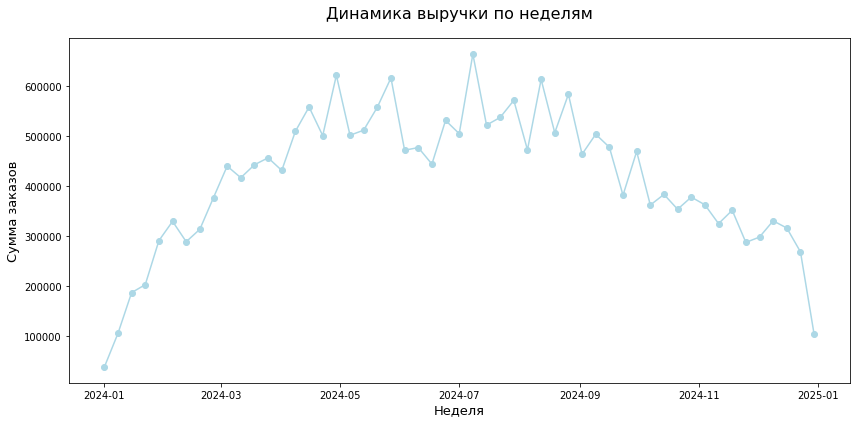

,order_week,revenue
0,2024-01-01,37953.82
1,2024-01-08,105410.12
2,2024-01-15,186852.94
3,2024-01-22,202773.73
4,2024-01-29,290757.55
5,2024-02-05,329235.88
6,2024-02-12,288530.97
7,2024-02-19,313445.98
8,2024-02-26,376724.90
9,2024-03-04,439609.94


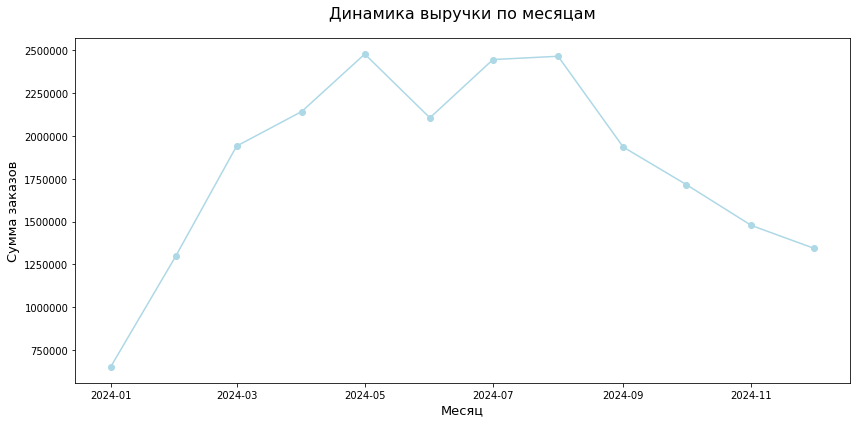

,order_month,revenue
0,2024-01-01,648890.03
1,2024-02-01,1296557.01
2,2024-03-01,1940749.79
3,2024-04-01,2142838.39
4,2024-05-01,2478758.10
5,2024-06-01,2106011.86
6,2024-07-01,2446535.45
7,2024-08-01,2465802.40
8,2024-09-01,1935366.70
9,2024-10-01,1716108.26


In [12]:
orders = pa_marketplace_orders.copy()
orders['revenue'] = orders['total_price']*0.05
pd.set_option('display.float_format', '{:.2f}'.format)

#рассчитаем revenue(выручку) по неделям 
orders_group_week = orders.groupby('order_week')['revenue'].sum().reset_index()

#рассчитаем revenue(выручку) по месяцам
orders_group_month = orders.groupby('order_month')['revenue'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(orders_group_week['order_week'], orders_group_week['revenue'], marker='o', color='lightblue')
plt.title('Динамика выручки по неделям', fontsize=16, pad=20)
plt.xlabel('Неделя', fontsize=13)
plt.ylabel('Сумма заказов', fontsize=13)
plt.tight_layout()
plt.show()
display(orders_group_week.head(10))

plt.figure(figsize=(12,6))
plt.plot(orders_group_month['order_month'], orders_group_month['revenue'], marker='o', color='lightblue')
plt.title('Динамика выручки по месяцам', fontsize=16, pad=20)
plt.xlabel('Месяц', fontsize=13)
plt.ylabel('Сумма заказов', fontsize=13)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()
display(orders_group_month)

#### Промежуточный вывод
По сравнению с началом года к концу маркетплейс демонстрирует рост. Значение выручки с января (640 тыс.) увеличилось практически вдвое к концу года ( 1 342 тыс.). Стоит отметить, что пиковый рост выручки маректплейс демонстрировал с апреля по август, затем началось снижение.

 ARPU за весь период: 591.9115989559508


,month,revenue,event_month,active_users,arpu
0,2024-01-01,648890.03,2024-01-01,1149,564.74
1,2024-02-01,1296557.01,2024-02-01,2162,599.70
2,2024-03-01,1940749.79,2024-03-01,2844,682.40
3,2024-04-01,2142838.39,2024-04-01,3059,700.50
4,2024-05-01,2478758.10,2024-05-01,3310,748.87
5,2024-06-01,2106011.86,2024-06-01,3174,663.52
6,2024-07-01,2446535.45,2024-07-01,3481,702.83
7,2024-08-01,2465802.40,2024-08-01,3861,638.64
8,2024-09-01,1935366.70,2024-09-01,3744,516.92
9,2024-10-01,1716108.26,2024-10-01,3581,479.23


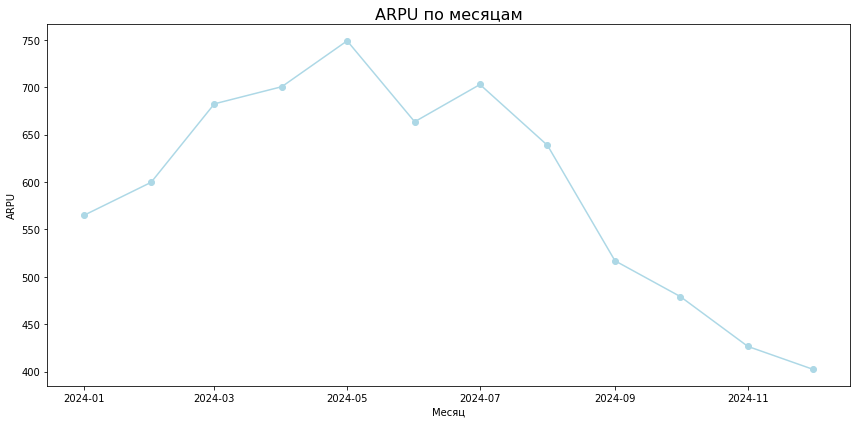

In [13]:
#расчет общего ARPU (Средняя выручка на одного пользователя)
events = pa_marketplace_events.copy()
total_revenue = orders['revenue'].sum()
amount_users = events.groupby('event_month')['user_id'].nunique().sum()
arpu = total_revenue/amount_users
print(f" ARPU за весь период: {arpu}")

#ARPU по месяцам
total_revenue_month = orders.groupby('order_month')['revenue'].sum().reset_index()
amount_users_month = events.groupby('event_month')['user_id'].nunique().reset_index()

# Объединяем
arpu_data = pd.merge(total_revenue_month, amount_users_month, left_on='order_month', right_on='event_month', how='outer')

# Переименовываем
arpu_data = arpu_data.rename(columns={'order_month': 'month', 'revenue': 'revenue', 'user_id': 'active_users'})

arpu_data['arpu'] = arpu_data['revenue'] / arpu_data['active_users']
display(arpu_data)

plt.figure(figsize=(12, 6))

plt.plot(arpu_data['month'], arpu_data['arpu'], color='lightblue', marker='o')
plt.title('ARPU по месяцам', fontsize=16)
plt.xlabel('Месяц')
plt.ylabel('ARPU')
plt.tight_layout()
plt.show()

#### Промежуточный вывод
Средняя выручка на пользователя за весь год составила - 592.

Рассматривая значение метрики ежемесячно можно отметить рост ARPU к середине года, затем ощутимый спад. Средняя выручка на одного пользователя сильно снизилась к концу года, несмотря на то, что кол-во пол-лей увеличилось практически в три раза.

DAU: user_id   306.00
dtype: float64 в среднем за день
WAU: user_id   1173.00
dtype: float64 в среднем за неделю


/tmp/ipykernel_197/3956533350.py:10: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  print(f"WAU: {round(wau.mean())} в среднем за неделю")


MAU: 3097 в среднем за месяц


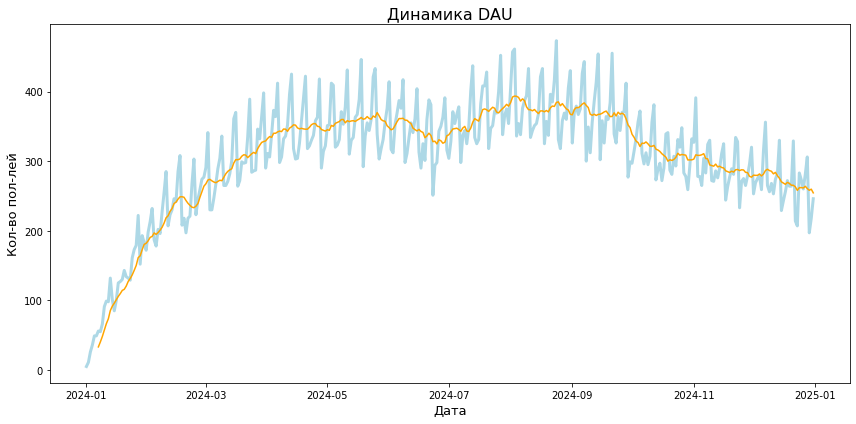

([<matplotlib.axis.XTick at 0x7f40d1236670>,
 [Text(0, 0, 'Jan 2024'),
  Text(1, 0, 'Feb 2024'),
  Text(2, 0, 'Mar 2024'),
  Text(3, 0, 'Apr 2024'),
  Text(4, 0, 'May 2024'),
  Text(5, 0, 'Jun 2024'),
  Text(6, 0, 'Jul 2024'),
  Text(7, 0, 'Aug 2024'),
  Text(8, 0, 'Sep 2024'),
  Text(9, 0, 'Oct 2024'),
  Text(10, 0, 'Nov 2024'),
  Text(11, 0, 'Dec 2024')])

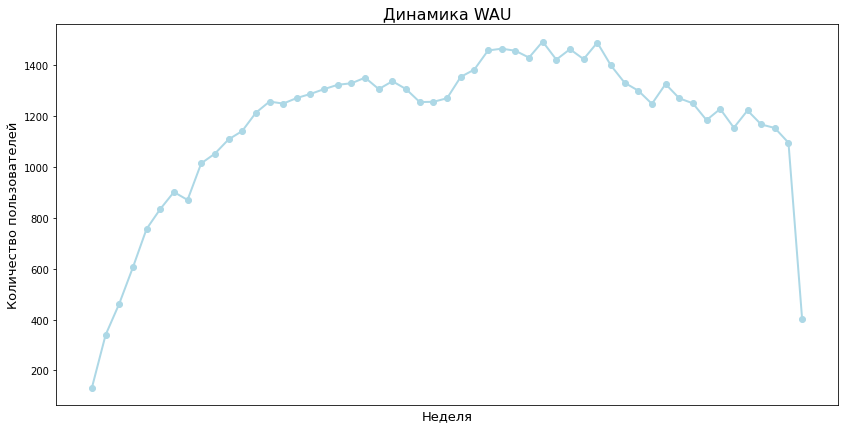

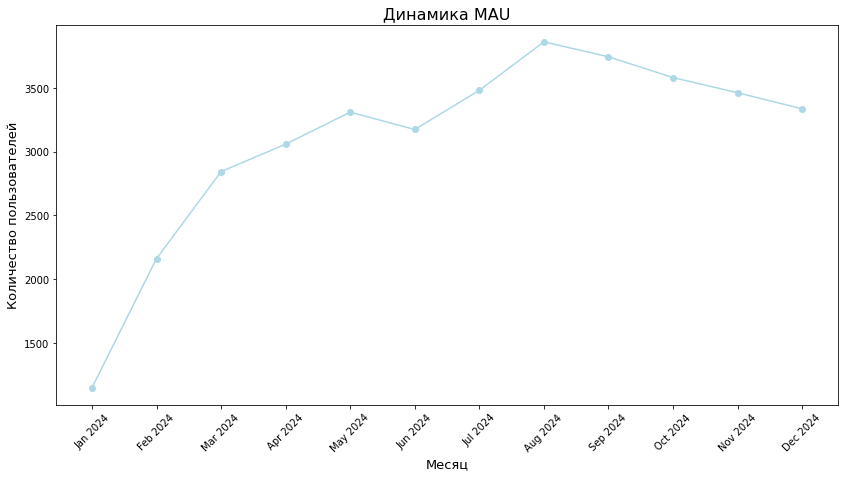

In [14]:
#расчет DAU, WAU, MAU
events_active = pa_marketplace_events.copy()

# DAU
dau = events_active.groupby(events_active['event_date'].dt.date)['user_id'].nunique().reset_index()
print(f"DAU: {round(dau.mean())} в среднем за день")

# WAU
wau = events_active.groupby('event_week')['user_id'].nunique().reset_index()
print(f"WAU: {round(wau.mean())} в среднем за неделю")

# MAU 
mau = events_active.groupby(events_active['event_date'].dt.to_period('M'))['user_id'].nunique()
print(f"MAU: {round(mau.mean())} в среднем за месяц")

dau['7day_rolling_avg'] = dau.user_id.rolling(7).mean()
#график DAU
plt.figure(figsize=(12, 6))
sns.lineplot(x='event_date', y='user_id', data = dau, color='lightblue', linewidth=3, markersize=6,
         markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2E86AB')
sns.lineplot(x='event_date', y='7day_rolling_avg', data = dau, color='orange')
plt.title('Динамика DAU', fontsize=16)
plt.xlabel('Дата', fontsize=13)
plt.ylabel('Кол-во пол-лей', fontsize=13)
plt.tight_layout()
plt.show()

# график WAU
plt.figure(figsize=(14, 7))
# Преобразуем event_week в строки для отображения
wau['event_week_str'] = wau['event_week'].dt.strftime('%d.%m.%Y')
plt.plot(wau['event_week_str'], wau['user_id'], 
         marker='o', linewidth=2, color='lightblue', markersize=6)
plt.title('Динамика WAU', fontsize=16)
plt.xlabel('Неделя', fontsize=13)
plt.ylabel('Количество пользователей', fontsize=13)
plt.xticks(rotation=45)
plt.xticks([])

# график MAU
mau_df = mau.reset_index()
mau_df.columns = ['month', 'mau_count']
mau_df['month_str'] = mau_df['month'].dt.strftime('%b %Y')

plt.figure(figsize=(14, 7))
plt.plot(mau_df['month_str'], mau_df['mau_count'], marker='o',
        color='lightblue')
plt.title('Динамика MAU', fontsize=16)
plt.xlabel('Месяц', fontsize=13)
plt.ylabel('Количество пользователей', fontsize=13)
plt.xticks(range(len(mau_df)), mau_df['month_str'], rotation=45)

In [15]:
display(dau)
display(wau)
display(mau)

,event_date,user_id,7day_rolling_avg
0,2024-01-01,5,NaN
1,2024-01-02,11,NaN
2,2024-01-03,26,NaN
3,2024-01-04,36,NaN
4,2024-01-05,49,NaN
...,...,...,...
361,2024-12-27,281,263.86
362,2024-12-28,306,260.57
363,2024-12-29,197,258.14
364,2024-12-30,218,259.71


,event_week,user_id,event_week_str
0,2024-01-01,133,01.01.2024
1,2024-01-08,340,08.01.2024
2,2024-01-15,463,15.01.2024
3,2024-01-22,606,22.01.2024
4,2024-01-29,757,29.01.2024
5,2024-02-05,835,05.02.2024
6,2024-02-12,902,12.02.2024
7,2024-02-19,871,19.02.2024
8,2024-02-26,1015,26.02.2024
9,2024-03-04,1053,04.03.2024


event_date
2024-01    1149
2024-02    2162
2024-03    2844
2024-04    3059
2024-05    3310
2024-06    3174
2024-07    3481
2024-08    3861
2024-09    3744
2024-10    3581
2024-11    3462
2024-12    3336
Freq: M, Name: user_id, dtype: int64

#### Промежуточный вывод
Анализ активности пользователей показал, что метрики увиличиваются на протяжении всего года, есть небольшие перепады, следовательно, интерес пользователей к маркетплейсу только возрастает.
По сравнению с началом года кол-во ежемесячных активных пользователей увеличилось практически в 3 раза.

### Вывод о динамике основных продуктовых метрик

Были рассмотрены метрики выручки, среднего дохода на пользователя и активности пол-лей (DAU, WAU, MAU).
В общем показатели демонстрируют положительную динамику, бизнес маркетплейса выглядит быстрорастущим. По показателю выручки по сравнению с началом года к концу маркетплейс демонстрирует рост. Значение выручки с января (640 тыс.) увеличилось практически вдвое к концу года ( 1 342 тыс.). Стоит отметить, что пиковый рост выручки маректплейс демонстрировал с апреля по август, затем началось небольшое снижение.

Анализ активности пользователей показал, что метрики увиличиваются на протяжении всего года, есть незначительные перепады, то есть интерес пользователей к маркетплейсу только возрастает. По сравнению с началом года кол-во ежемесячных активных пользователей увеличилось практически в 3 раза.

Рассматривая значение метрики ARPU ежемесячно можно отметить рост к середине года, затем ощутимый спад. Средняя выручка на одного пользователя сильно снизилась к концу года, несмотря на то, что кол-во пол-лей увеличилось практически в три раза. 
Стоит обратить внимание на то, что средняя выручка падает - тревожный сигнал.

### 3. Оценка метрик монетизации и юнит-экономики

Выполним анализ монетизации. Определим, сколько зарабатывает продукт и сколько тратит на привлечение.


,month,revenue,costs
0,2024-01-01,648890.03,1177456.97
1,2024-02-01,1296557.01,1061385.93
2,2024-03-01,1940749.79,1167680.37
3,2024-04-01,2142838.39,1147739.92
4,2024-05-01,2478758.10,1225322.28
5,2024-06-01,2106011.86,1130439.77
6,2024-07-01,2446535.45,1776446.60
7,2024-08-01,2465802.40,1811677.75
8,2024-09-01,1935366.70,1820718.83
9,2024-10-01,1716108.26,1810802.57


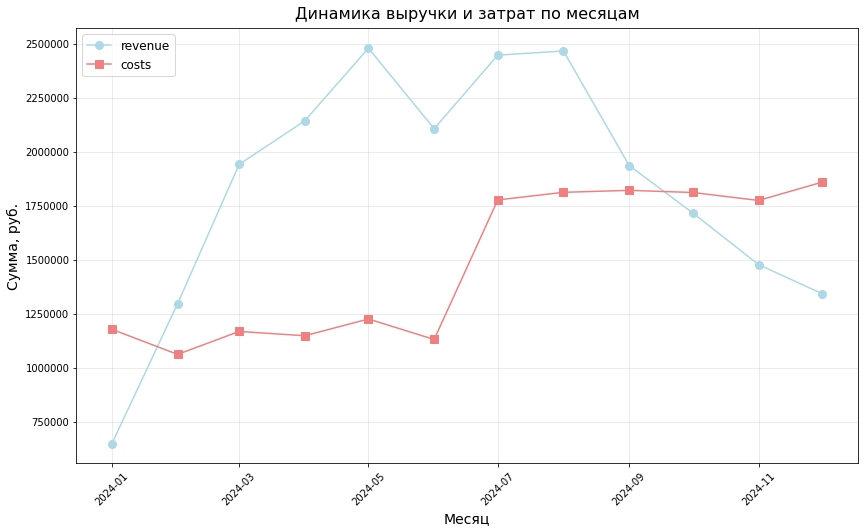

In [16]:
#расчет выручки
orders_unit = pa_marketplace_orders.copy()
orders_unit['revenue'] = orders_unit['total_price']*0.05

#рассчитаем revenue(выручку) по месяцам
orders_unit_month = orders.groupby('order_month')['revenue'].sum().reset_index()

#расчет затрат 
costs_unit = pa_marketplace_campaign_costs.copy()
costs_unit_month = costs_unit.groupby('spend_month')['budget'].sum().reset_index()

# Объединяем данные, переименовывая для удобства
analysis_df = pd.merge(
    orders_unit_month.rename(columns={'order_month': 'month', 'revenue': 'revenue'}),
    costs_unit_month.rename(columns={'spend_month': 'month', 'budget': 'costs'}),
    on='month',
    how='outer').sort_values('month')

# Заполняем пропущенные значения нулями
analysis_df = analysis_df.fillna(0)
analysis_df = analysis_df.iloc[:-1]

# График с двумя линиями
plt.figure(figsize=(14, 8))

# Линия выручки
plt.plot(analysis_df['month'], analysis_df['revenue'], marker='o', color='lightblue', label='revenue', markersize=8)
# Линия затрат
plt.plot(analysis_df['month'], analysis_df['costs'], 
         marker='s', color='lightcoral', label='costs', markersize=8)

# Настройки графика
plt.title('Динамика выручки и затрат по месяцам', fontsize=16, pad = 10)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('Сумма, руб.', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
display(analysis_df)

#### Промежуточный вывод
По графику выручки и затрат видно, что большую часть времени выручка превышает затраты.

Общий ROI по месяцам:


,month_str,month,total_profit,total_costs,profit_loss,roi
0,01-01-2024,2024-01-01,648890.03,1177456.97,-528566.94,-44.89
1,01-02-2024,2024-02-01,1296557.01,1061385.93,235171.08,22.16
2,01-03-2024,2024-03-01,1940749.79,1167680.37,773069.42,66.21
3,01-04-2024,2024-04-01,2142838.39,1147739.92,995098.48,86.70
4,01-05-2024,2024-05-01,2478758.10,1225322.28,1253435.82,102.29
5,01-06-2024,2024-06-01,2106011.86,1130439.77,975572.09,86.30
6,01-07-2024,2024-07-01,2446535.45,1776446.60,670088.85,37.72
7,01-08-2024,2024-08-01,2465802.40,1811677.75,654124.64,36.11
8,01-09-2024,2024-09-01,1935366.70,1820718.83,114647.87,6.30
9,01-10-2024,2024-10-01,1716108.26,1810802.57,-94694.31,-5.23


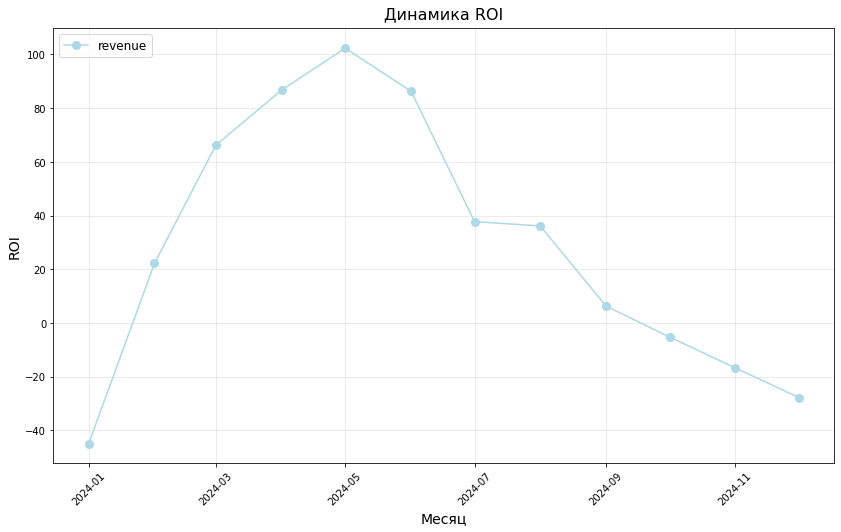

In [17]:
# Общая выручка по месяцам (прибыль 5%)
orders = pa_marketplace_orders.copy()
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['profit'] = orders['total_price'] * 0.05  # маржа 5%
monthly_profit = orders.groupby(orders['order_date'].dt.to_period('M').dt.to_timestamp())['profit'].sum().reset_index()
monthly_profit.columns = ['month', 'total_profit']

# Общие затраты по месяцам
costs = pa_marketplace_campaign_costs.copy()
costs['month'] = pd.to_datetime(costs['spend_month'])
monthly_costs = costs.groupby('month')['budget'].sum().reset_index()
monthly_costs.columns = ['month', 'total_costs']

# Объединяем данные
roi_calculation = pd.merge(monthly_profit, monthly_costs, on='month', how='inner')

# Рассчитываем общий ROI
roi_calculation['profit_loss'] = roi_calculation['total_profit'] - roi_calculation['total_costs']
roi_calculation['roi'] = (roi_calculation['profit_loss'] / roi_calculation['total_costs']) * 100

# Сортируем по дате
roi_calculation = roi_calculation.sort_values('month')

# Добавляем отформатированную дату
roi_calculation['month_str'] = roi_calculation['month'].dt.strftime('%d-%m-%Y')

print("Общий ROI по месяцам:")
display(roi_calculation[['month_str', 'month', 'total_profit', 'total_costs', 'profit_loss', 'roi']])

# График с двумя линиями
plt.figure(figsize=(14, 8))

# Линия выручки
plt.plot(roi_calculation['month'], roi_calculation['roi'], marker='o', color='lightblue', label='revenue', markersize=8)

# Настройки графика
plt.title('Динамика ROI', fontsize=16, pad = 10)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('ROI', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

#### Промежуточный вывод
По графику общей рентабельности можно омтетить, что большую часть времени коэффициент рентабельности положительный, то есть бизнес приносит прибыль. К тому же, отметим, что есть явная сезонность, с апреля по июнь показатели рентабельности достигают значений от 86% до 100%

1. CAC по месяцам привлечения:


,month,new_users,total_costs,cac
0,2024-01-01,2985,1177456.97,394.46
1,2024-02-01,2711,1061385.93,391.51
2,2024-03-01,2965,1167680.37,393.82
3,2024-04-01,2905,1147739.92,395.09
4,2024-05-01,3066,1225322.28,399.65
5,2024-06-01,2810,1130439.77,402.29
6,2024-07-01,4388,1776446.60,404.84
7,2024-08-01,4431,1811677.75,408.86
8,2024-09-01,4466,1820718.83,407.68
9,2024-10-01,4440,1810802.57,407.84



2. LTV по месяцам привлечения:


,month,cohort_size,total_profit,ltv
0,2024-01-01,837,2105090.29,2515.04
1,2024-02-01,804,2052689.15,2553.10
2,2024-03-01,877,2481937.70,2830.03
3,2024-04-01,911,2456668.31,2696.67
4,2024-05-01,854,2246673.71,2630.77
5,2024-06-01,716,1891357.64,2641.56
6,2024-07-01,998,2480705.40,2485.68
7,2024-08-01,810,1883228.28,2324.97
8,2024-09-01,668,1446349.32,2165.19
9,2024-10-01,495,1107371.11,2237.11



3. Итоговый анализ (CAC, LTV, ROI) по месяцам привлечения:


,month_str,month,cohort_size,total_profit,cac,ltv,roi
0,01-01-2024,2024-01-01,837,2105090.29,394.46,2515.04,537.59
1,01-02-2024,2024-02-01,804,2052689.15,391.51,2553.10,552.11
2,01-03-2024,2024-03-01,877,2481937.70,393.82,2830.03,618.61
3,01-04-2024,2024-04-01,911,2456668.31,395.09,2696.67,582.54
4,01-05-2024,2024-05-01,854,2246673.71,399.65,2630.77,558.27
5,01-06-2024,2024-06-01,716,1891357.64,402.29,2641.56,556.63
6,01-07-2024,2024-07-01,998,2480705.40,404.84,2485.68,513.99
7,01-08-2024,2024-08-01,810,1883228.28,408.86,2324.97,468.64
8,01-09-2024,2024-09-01,668,1446349.32,407.68,2165.19,431.10
9,01-10-2024,2024-10-01,495,1107371.11,407.84,2237.11,448.53


No handles with labels found to put in legend.


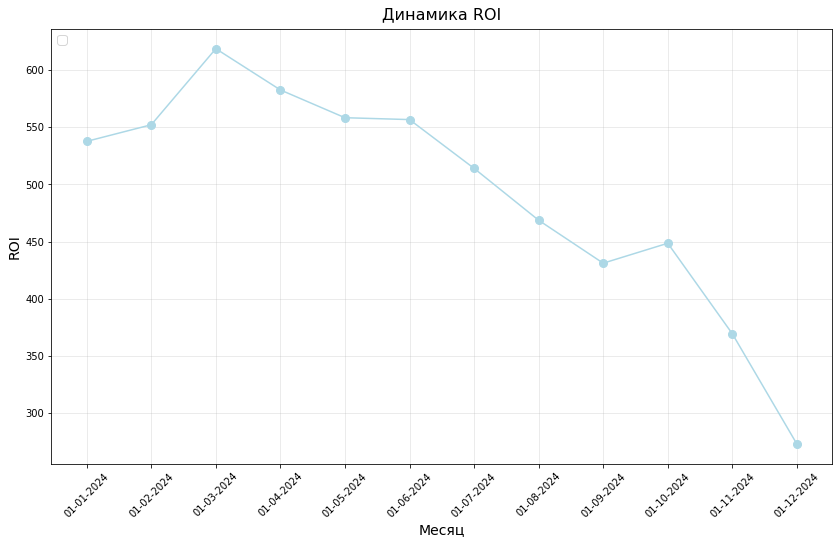

In [18]:
# 1. CAC - по месяцам привлечения (cohort_month)
users = pa_marketplace_users.copy()
costs = pa_marketplace_campaign_costs.copy()

# Приводим даты к одному формату
users['cohort_month'] = pd.to_datetime(users['cohort_month'])
costs['month'] = pd.to_datetime(costs['spend_month'])

# Количество новых пользователей по месяцам
new_users_by_month = users.groupby('cohort_month')['user_id'].nunique().reset_index()
new_users_by_month.columns = ['month', 'new_users']

# Затраты по месяцам
costs_by_month = costs.groupby('month')['budget'].sum().reset_index()
costs_by_month.columns = ['month', 'total_costs']

# Объединяем и считаем CAC
cac_calculation = pd.merge(new_users_by_month, costs_by_month, on='month', how='left')
cac_calculation['cac'] = cac_calculation['total_costs'] / cac_calculation['new_users']

print("1. CAC по месяцам привлечения:")
display(cac_calculation[['month', 'new_users', 'total_costs', 'cac']])

# 2. LTV - по тем же месяцам привлечения (cohort_month)
orders = pa_marketplace_orders.copy()
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Добавляем информацию о месяце привлечения пользователя
orders_with_cohort = pd.merge(
    orders,
    users[['user_id', 'cohort_month']],
    on='user_id',
    how='left')

# Считаем прибыль (5% маржа)
orders_with_cohort['profit'] = orders_with_cohort['total_price'] * 0.05

# Группируем по месяцам привлечения - считаем общую прибыль каждой когорты
ltv_calculation = orders_with_cohort.groupby('cohort_month').agg(
    total_profit=('profit', 'sum'),
    unique_users=('user_id', 'nunique')).reset_index()

ltv_calculation.columns = ['month', 'total_profit', 'cohort_size']

# LTV = Общая прибыль когорты / Размер когорты
ltv_calculation['ltv'] = ltv_calculation['total_profit'] / ltv_calculation['cohort_size']

print("\n2. LTV по месяцам привлечения:")
display(ltv_calculation[['month', 'cohort_size', 'total_profit', 'ltv']])

# 3. Объединяем CAC и LTV по месяцам
analysis = pd.merge(
    cac_calculation[['month', 'cac']],
    ltv_calculation[['month', 'ltv', 'cohort_size', 'total_profit']],
    on='month',
    how='inner')

# 4. ROI = (LTV - CAC) / CAC * 100
analysis['roi'] = (analysis['ltv'] - analysis['cac']) / analysis['cac'] * 100

# Сортируем по дате
analysis = analysis.sort_values('month')
analysis['month_str'] = analysis['month'].dt.strftime('%d-%m-%Y')

print("\n3. Итоговый анализ (CAC, LTV, ROI) по месяцам привлечения:")
display(analysis[['month_str', 'month', 'cohort_size', 'total_profit', 'cac', 'ltv', 'roi']])

# График с двумя линиями
plt.figure(figsize=(14, 8))

# Линия выручки
plt.plot(analysis['month_str'], analysis['roi'], marker='o', color='lightblue', markersize=8)

# Настройки графика
plt.title('Динамика ROI', fontsize=16, pad = 10)
plt.xlabel('Месяц', fontsize=14)
plt.ylabel('ROI', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

In [19]:
# Создаем таблицу с помесячной прибылью по когортам
orders_with_cohort['order_month'] = orders_with_cohort['order_date'].dt.to_period('M').dt.to_timestamp()

# Считаем разницу в месяцах
orders_with_cohort['months_since_cohort'] = (
    (orders_with_cohort['order_month'].dt.year - orders_with_cohort['cohort_month'].dt.year) * 12 +
    (orders_with_cohort['order_month'].dt.month - orders_with_cohort['cohort_month'].dt.month))

# Группируем прибыль по когортам и месяцам
monthly_profit_by_cohort = orders_with_cohort.groupby([
    'cohort_month', 
    'months_since_cohort'])['profit'].sum().reset_index()

monthly_profit_by_cohort.columns = ['month', 'months_since_cohort', 'monthly_profit']

# Добавляем общие затраты
monthly_profit_by_cohort = pd.merge(monthly_profit_by_cohort, cac_calculation[['month', 'total_costs']], on='month', how='left')

# Сортируем по когорте и месяцам
monthly_profit_by_cohort = monthly_profit_by_cohort.sort_values(['month', 'months_since_cohort'])

# Считаем накопленную прибыль
monthly_profit_by_cohort['cumulative_profit'] = monthly_profit_by_cohort.groupby('month')['monthly_profit'].cumsum()

# Рассчитываем Payback Period для каждой когорты вручную
payback_data = []

# Получаем уникальные когорты
unique_cohorts = monthly_profit_by_cohort['month'].unique()

for cohort in unique_cohorts:
    # Берем данные по текущей когорте
    cohort_data = monthly_profit_by_cohort[monthly_profit_by_cohort['month'] == cohort].copy()
    cohort_data = cohort_data.sort_values('months_since_cohort')
    
    total_costs = cohort_data['total_costs'].iloc[0]
    payback_month = None
    payback_period_months = None
    payback_period_days = None
    final_cumulative = cohort_data['cumulative_profit'].iloc[-1]
    
    # Перебираем месяцы по порядку
    for i in range(len(cohort_data)):
        current_row = cohort_data.iloc[i]
        
        # Проверяем, достигла ли накопленная прибыль затрат
        if current_row['cumulative_profit'] >= total_costs:
            payback_month = current_row['months_since_cohort']
            
            # Если окупились в первый месяц
            if payback_month == 0:
                if current_row['monthly_profit'] > 0:
                    payback_period_months = total_costs / current_row['monthly_profit']
                else:
                    payback_period_months = 0
            else:
                # Находим данные за предыдущий месяц
                prev_month = payback_month - 1
                prev_row = cohort_data[cohort_data['months_since_cohort'] == prev_month]
                
                if len(prev_row) > 0:
                    prev_cumulative = prev_row['cumulative_profit'].iloc[0]
                    remaining = total_costs - prev_cumulative
                    
                    if current_row['monthly_profit'] > 0:
                        payback_period_months = prev_month + (remaining / current_row['monthly_profit'])
                    else:
                        payback_period_months = None
                else:
                    payback_period_months = payback_month
            
            if payback_period_months is not None:
                payback_period_days = payback_period_months * 30.44
            
            break
    
    # Если не нашли точку окупаемости
    if payback_month is None:
        last_month = cohort_data['months_since_cohort'].iloc[-1]
        payback_period_months = f'> {last_month}'
    
    # Добавляем результат
    payback_data.append({
        'month': cohort,
        'total_costs': total_costs,
        'payback_month': payback_month,
        'payback_period_months': payback_period_months,
        'payback_period_days': payback_period_days,
        'final_cumulative': final_cumulative})

# Создаем DataFrame с результатами
payback_df = pd.DataFrame(payback_data)

# Объединяем с основными данными
payback_full = pd.merge(
    analysis[['month', 'month_str', 'cohort_size', 'ltv', 'cac', 'roi']],
    payback_df,
    on='month',
    how='left')

summary = payback_full.copy()
summary['payback_status'] = summary['payback_period_months'].apply(
    lambda x: 'Окупилась' if isinstance(x, (int, float)) else 'Не окупилась')

# Для числовых значений округляем
numeric_cols = ['cac', 'ltv', 'roi']
for col in numeric_cols:
    summary[col] = summary[col].round(2)

# Отображаем сводную таблицу
display(summary[['month_str', 'cohort_size', 'cac', 'ltv', 'roi', 
                 'payback_period_months', 'payback_status']])

,month_str,cohort_size,cac,ltv,roi,payback_period_months,payback_status
0,01-01-2024,837,394.46,2515.04,537.59,0.80,Окупилась
1,01-02-2024,804,391.51,2553.10,552.11,0.62,Окупилась
2,01-03-2024,877,393.82,2830.03,618.61,0.60,Окупилась
3,01-04-2024,911,395.09,2696.67,582.54,0.49,Окупилась
4,01-05-2024,854,399.65,2630.77,558.27,0.58,Окупилась
5,01-06-2024,716,402.29,2641.56,556.63,0.79,Окупилась
6,01-07-2024,998,404.84,2485.68,513.99,1.10,Окупилась
7,01-08-2024,810,408.86,2324.97,468.64,2.87,Окупилась
8,01-09-2024,668,407.68,2165.19,431.10,> 3.0,Не окупилась
9,01-10-2024,495,407.84,2237.11,448.53,> 2.0,Не окупилась


#### Промежуточный вывод
Все когорты имеют ROI от 273% до 619% - отличный показатель. Опять же замечаем сильную сезонность.

### Выводы об оценке метрик монетизации и юнит-экономики

1. Общая рентабельность маркетинга (Общий ROI): сильная сезонность (в начале года ROI достигает 100%+, во второй половине падает до отрицательных значений); лучшие месяцы - май (102.3%), апрель (86.7%), июнь (86.3%); проблемные месяцы - январь (-44.9%), октябрь-декабрь (отрицательный ROI), средний ROI за год: ~35% (прибыльные месяцы компенсируют убыточные).
   
2. Эффективность привлечение клиентов (LTV/CAC): высокая эффективность (все когорты имеют ROI от 273% до 619% - отличный показатель); стабильный CAC (стоимость привлечения держится на уровне 390-410 ₽), высокий LTV (пожизненная ценность клиентов составляет 1500-2800 ₽). 

3. Срок окупаемости (Payback Period): быстрая окупаемость (7 из 12 когорт окупились за 0.5-1.1 месяца (15-33 дня)); хорошие показатели (средний срок окупаемости ~1 месяц); поздние когорты (когорты сентября-декабря ещё не окупились из-за недостатка времени).

## Выводы по этапам 2 и 3


Были рассмотрены метрики выручки, среднего дохода на пользователя и активности пол-лей (DAU, WAU, MAU).
В общем показатели демонстрируют положительную динамику, бизнес маркетплейса выглядит быстрорастущим. По показателю выручки по сравнению с началом года к концу маркетплейс демонстрирует рост. Значение выручки с января (640 тыс.) увеличилось практически вдвое к концу года ( 1 342 тыс.). Стоит отметить, что пиковый рост выручки маректплейс демонстрировал с апреля по август, затем началось небольшое снижение.

Анализ активности пользователей показал, что метрики увиличиваются на протяжении всего года, есть незначительные перепады, то есть интерес пользователей к маркетплейсу только возрастает. По сравнению с началом года кол-во ежемесячных активных пользователей увеличилось практически в 3 раза.

Рассматривая значение метрики ARPU ежемесячно можно отметить рост к середине года, затем ощутимый спад. Средняя выручка на одного пользователя сильно снизилась к концу года, несмотря на то, что кол-во пол-лей увеличилось практически в три раза. 
Стоит обратить внимание на то, что средняя выручка падает - тревожный сигнал.

Общая рентабельность маркетинга (Общий ROI): сильная сезонность (в начале года ROI достигает 100%+, во второй половине падает до отрицательных значений); лучшие месяцы - май (102.3%), апрель (86.7%), июнь (86.3%); проблемные месяцы - январь (-44.9%), октябрь-декабрь (отрицательный ROI), средний ROI за год: ~35% (прибыльные месяцы компенсируют убыточные).

Эффективность привлечение клиентов (LTV/CAC): высокая эффективность (все когорты имеют ROI от 273% до 619% - отличный показатель); стабильный CAC (стоимость привлечения держится на уровне 390-410 ₽), высокий LTV (пожизненная ценность клиентов составляет 1500-2800 ₽).

Срок окупаемости (Payback Period): быстрая окупаемость (7 из 12 когорт окупились за 0.5-1.1 месяца (15-33 дня)); хорошие показатели (средний срок окупаемости ~1 месяц); поздние когорты (когорты сентября-декабря ещё не окупились из-за недостатка времени).

- Контраст метрик:оычный ROI показывает проблемы с ликвидностью, а LTV/CAC - высокую долгосрочную эффективность;
   
- Высокая ценность клиентов: несмотря на отрицательный месячный ROI, клиенты приносят прибыль в долгосрочной перспективе;
   
- Сезонные колебания: эффективность снижается к концу года - нужно анализировать причины.

Вывод: Маркетинговая стратегия в целом эффективна, но требует оптимизации управления денежными потоками и анализа сезонных колебаний. Также, из всего вышеперечисленного мы видим снижение выручки, под влиянием снижения среднего чего и прибыли, которую приносит один поль-ль, в то врема как затраты на привлечение одного клиента не меняеются, но общие затраты к концу года выросли, следовательно, возросло кол-во активных пол-лей. В последующем анализы, необходимо обратить внимание на возможные причины снижения ARPU.

## 4. Поиск инсайтов, точек роста и сегментация


Рассмотрим данные по каналам, сегментам пользователей, категориям товаров, регионам, типам устройств. 

Цель — сформировать обоснованные гипотезы:

* какие сегменты работают лучше остальных
* какие сегменты работают хуже остальных
* на каких этапах воронки теряются пользователи
* какие группы можно или нужно масштабировать
* куда стоит инвестировать больше внимания или ресурсов


In [20]:
#ПОСТРОЕНИЕ ВОРОНКИ
voronka_df = pa_marketplace_events.copy()

funnel_steps = ['page_view', 'product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

voronka_df = voronka_df.groupby('event_type')['user_id'].nunique().reindex(funnel_steps).reset_index()
voronka_df = voronka_df.rename(columns={'user_id':'users_n'})

voronka_df['users_n'] = voronka_df['users_n'].fillna(0)

voronka_df['conversion_classic'] = voronka_df['users_n']/voronka_df['users_n'].iloc[0]*100
voronka_df['conversion_step_by_step'] = voronka_df['users_n']/voronka_df['users_n'].shift(1)*100

display(voronka_df.head(10))

,event_type,users_n,conversion_classic,conversion_step_by_step
0,page_view,22098,100.00,NaN
1,product_view,22069,99.87,99.87
2,add_to_cart,20411,92.37,92.49
3,checkout_start,16769,75.88,82.16
4,checkout_complete,13897,62.89,82.87


#### Промежуточный вывод
Оформление заказа эффективно: 82.87% начавших оформление завершают его. Процесс покупки отлажен: пользователям легко пройти от корзины до оформления заказа.Нет технических проблем на поздних этапах. По классической воронке видно, что мы теряем 37% посетителей до оформления заказа. Посетители смотрят товары, но не покупают


Сравнительная таблица по устройствам:


,Устройство,ARPU,Выручка,Пользователи,"Доля выручки, %","Доля пользователей, %",Эффективность (ARPU)
0,mobile,2960.20,21997210.75,7431,33.33,33.57,2960.20
1,desktop,2953.84,21997210.75,7447,33.33,33.64,2953.84
2,tablet,3029.92,21997210.75,7260,33.33,32.79,3029.92


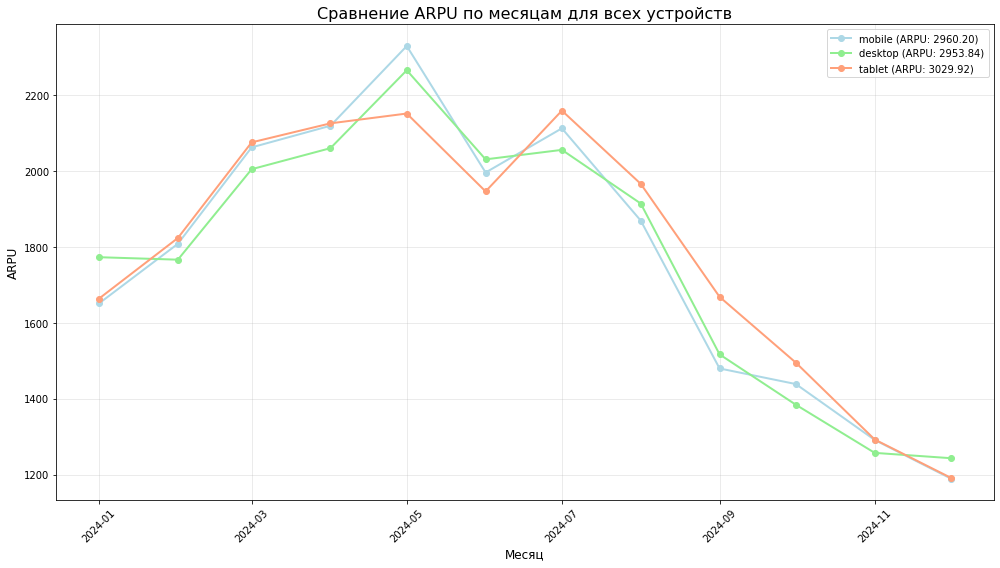

In [21]:
# Создаем словарь для хранения результатов всех устройств
device_results = {}

# Список устройств для анализа
devices = ['mobile', 'desktop', 'tablet']
colors = ['lightblue', 'lightgreen', 'lightsalmon']

# Общий цикл по всем устройствам
for i, device in enumerate(devices): 
    # Фильтруем события по устройству
    events_device = pa_marketplace_events.copy()
    events_device = events_device[events_device['device'] == device]
    # Используем общую таблицу заказов
    orders_device = orders_group_month.copy()
    # Расчет общего ARPU
    total_revenue_device = orders_device['revenue'].sum()
    amount_users_device = events_device['user_id'].nunique() 
    arpu_device = total_revenue_device / amount_users_device if amount_users_device > 0 else 0
    # ARPU по месяцам
    total_revenue_month_device = orders_device.groupby('order_month')['revenue'].sum().reset_index()
    amount_users_month_device = events_device.groupby('event_month')['user_id'].nunique().reset_index()
    # Объединяем
    arpu_data_device = pd.merge(
        total_revenue_month_device, 
        amount_users_month_device, 
        left_on='order_month', 
        right_on='event_month', 
        how='outer')
    # Переименовываем
    arpu_data_device = arpu_data_device.rename(columns={
        'order_month': 'month', 
        'revenue': 'revenue', 
        'user_id': 'active_users'})
    # Расчет ARPU по месяцам
    arpu_data_device['arpu'] = arpu_data_device['revenue'] / arpu_data_device['active_users']    
    # Сохраняем результаты
    device_results[device] = {
        'arpu_total': arpu_device,
        'total_revenue': total_revenue_device,
        'total_users': amount_users_device,
        'arpu_monthly': arpu_data_device,
        'color': colors[i]}


# Сравнительный анализ всех устройств
# Создаем таблицу сравнения
comparison_table = pd.DataFrame({
    'Устройство': devices,
    'ARPU': [device_results[device]['arpu_total'] for device in devices],
    'Выручка': [device_results[device]['total_revenue'] for device in devices],
    'Пользователи': [device_results[device]['total_users'] for device in devices]})

# Добавляем дополнительные метрики
comparison_table['Доля выручки, %'] = (comparison_table['Выручка'] / comparison_table['Выручка'].sum() * 100).round(2)
comparison_table['Доля пользователей, %'] = (comparison_table['Пользователи'] / comparison_table['Пользователи'].sum() * 100).round(2)
comparison_table['Эффективность (ARPU)'] = comparison_table['ARPU']

print("\nСравнительная таблица по устройствам:")
display(comparison_table)

# Сравнительный график ARPU по месяцам для всех устройств
plt.figure(figsize=(14, 8))

for device in devices:
    arpu_monthly = device_results[device]['arpu_monthly']
    color = device_results[device]['color']
    plt.plot(arpu_monthly['month'], arpu_monthly['arpu'], 
             color=color, marker='o', linewidth=2, markersize=6, 
             label=f'{device} (ARPU: {device_results[device]["arpu_total"]:.2f})')

plt.title('Сравнение ARPU по месяцам для всех устройств', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('ARPU', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Операционная система,ARPU,Выручка,Пользователи,"Доля выручки, %","Доля пользователей, %",Эффективность (ARPU)
0,macOS,4060.02,21997210.75,5418,25.00,24.47,4060.02
1,Android,3982.84,21997210.75,5523,25.00,24.95,3982.84
2,Windows,3932.29,21997210.75,5594,25.00,25.27,3932.29
3,iOS,3925.97,21997210.75,5603,25.00,25.31,3925.97


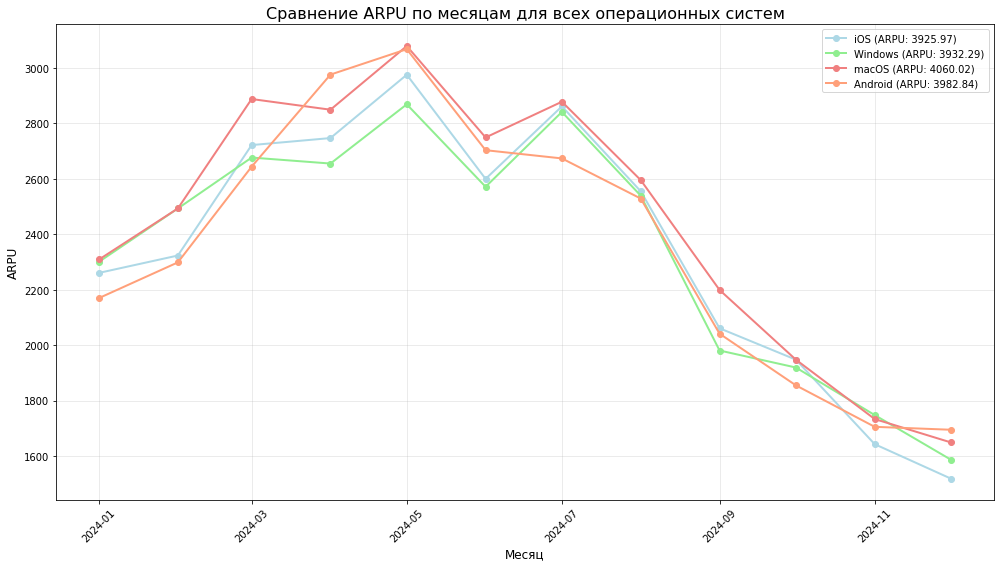

In [22]:
# Создаем словарь для хранения результатов всех OS
os_results = {}

# Список операционных систем для анализа
os_list = ['iOS', 'Windows', 'macOS', 'Android']
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon']

# Общий цикл по всем OS
for i, os_name in enumerate(os_list):    
    # Фильтруем события по OS
    events_os = pa_marketplace_events.copy()
    events_os = events_os[events_os['os'] == os_name]
    
    # Проверяем, есть ли данные для этой OS
    if len(events_os) == 0:
        print(f"Нет данных для {os_name}")
        continue
    
    # Используем общую таблицу заказов
    orders_os = orders_group_month.copy()
    
    # Расчет общего ARPU
    total_revenue_os = orders_os['revenue'].sum()
    amount_users_os = events_os['user_id'].nunique()  # Уникальные пользователи за весь период
    arpu_os = total_revenue_os / amount_users_os if amount_users_os > 0 else 0
    
    # ARPU по месяцам
    total_revenue_month_os = orders_os.groupby('order_month')['revenue'].sum().reset_index()
    amount_users_month_os = events_os.groupby('event_month')['user_id'].nunique().reset_index()
    
    # Объединяем
    arpu_data_os = pd.merge(
        total_revenue_month_os, 
        amount_users_month_os, 
        left_on='order_month', 
        right_on='event_month', 
        how='outer')
    
    # Переименовываем
    arpu_data_os = arpu_data_os.rename(columns={
        'order_month': 'month', 
        'revenue': 'revenue', 
        'user_id': 'active_users'})
    
    # Расчет ARPU по месяцам
    arpu_data_os['arpu'] = arpu_data_os['revenue'] / arpu_data_os['active_users']
    
    # Сохраняем результаты
    os_results[os_name] = {
        'arpu_total': arpu_os,
        'total_revenue': total_revenue_os,
        'total_users': amount_users_os,
        'arpu_monthly': arpu_data_os,
        'color': colors[i]}

# Проверяем, есть ли данные
if len(os_results) == 0:
    print("Нет данных ни для одной операционной системы!")
else:
    # Создаем таблицу сравнения
    comparison_table = pd.DataFrame({
        'Операционная система': list(os_results.keys()),
        'ARPU': [os_results[os]['arpu_total'] for os in os_results],
        'Выручка': [os_results[os]['total_revenue'] for os in os_results],
        'Пользователи': [os_results[os]['total_users'] for os in os_results]})
    
    # Сортируем по ARPU (от большего к меньшему)
    comparison_table = comparison_table.sort_values('ARPU', ascending=False).reset_index(drop=True)
    
    # Добавляем дополнительные метрики
    comparison_table['Доля выручки, %'] = (comparison_table['Выручка'] / comparison_table['Выручка'].sum() * 100).round(2)
    comparison_table['Доля пользователей, %'] = (comparison_table['Пользователи'] / comparison_table['Пользователи'].sum() * 100).round(2)
    comparison_table['Эффективность (ARPU)'] = comparison_table['ARPU']
    display(comparison_table)
    
    # Сравнительный график ARPU по месяцам для всех OS
    plt.figure(figsize=(14, 8))
    for os_name in os_results:
        arpu_monthly = os_results[os_name]['arpu_monthly']
        color = os_results[os_name]['color']
        plt.plot(
            arpu_monthly['month'], 
            arpu_monthly['arpu'], 
            color=color, 
            marker='o', 
            linewidth=2, 
            markersize=6, 
            label=f'{os_name} (ARPU: {os_results[os_name]["arpu_total"]:.2f})')    
    plt.title('Сравнение ARPU по месяцам для всех операционных систем', fontsize=16)
    plt.xlabel('Месяц', fontsize=12)
    plt.ylabel('ARPU', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Промежуточный вывод
Закономерности между уменьшением выручки и использование различных типой устройств и операционных систем не выявлено.

,acq_channel,order_month,revenue
0,Affiliate,2024-01-01,151314.19
1,Affiliate,2024-02-01,379698.20
2,Affiliate,2024-03-01,593648.76
3,Affiliate,2024-04-01,592853.13
4,Affiliate,2024-05-01,781871.77


(array([19723., 19783., 19844., 19905., 19967., 20028.]),
 [Text(19723.0, 0, '2024-01'),
  Text(19783.0, 0, '2024-03'),
  Text(19844.0, 0, '2024-05'),
  Text(19905.0, 0, '2024-07'),
  Text(19967.0, 0, '2024-09'),
  Text(20028.0, 0, '2024-11')])

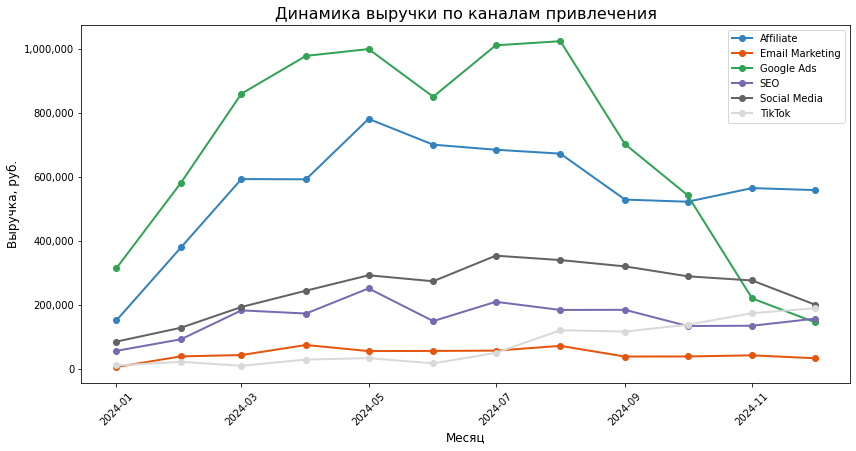

In [23]:
# ДОХОД ОТ КАНАЛОВ ПОМЕСЯЧНО
orders_ren = pa_marketplace_orders.copy()
users_ren = pa_marketplace_users.copy()
orders_users = pd.merge(orders_ren, users_ren, how='left', on='user_id')
orders_users['revenue'] = orders_users['total_price']*0.05

channel_sum = orders_users.groupby(['acq_channel', 'order_month'])['revenue'].sum().reset_index()
display(channel_sum.head())

plt.figure(figsize=(12, 6))
channels = channel_sum['acq_channel'].unique()

# Используем colormap для генерации цветов
colors = cm.tab20c(np.linspace(0, 1, len(channels)))  

for idx, channel in enumerate(channels): 
    channel_data = channel_sum[channel_sum['acq_channel'] == channel].sort_values('order_month')
    if len(channel_data) > 0:
        plt.plot(channel_data['order_month'], channel_data['revenue'],  
                 marker='o', linewidth=2, markersize=6, 
                 color=colors[idx],  
                 label=channel)

# Форматируем ось Y (убираем научную нотацию)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
plt.title('Динамика выручки по каналам привлечения', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка, руб.', fontsize=12)
plt.legend()
plt.tight_layout()
plt.xticks(rotation=45)

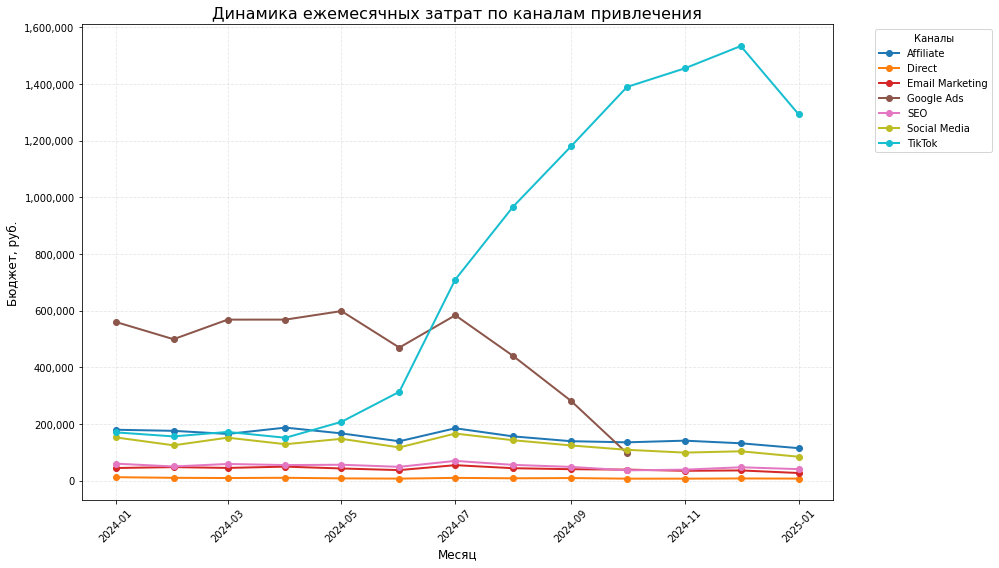

In [24]:
#ДИНАМИКА ЗАТРАТ ПО КАНАЛАМ ЕЖЕМЕСЯЧНО
costs_channel = pa_marketplace_campaign_costs.copy()
costs_channel = costs_channel.groupby(['acq_channel', 'spend_month'])['budget'].sum().reset_index()

# Получаем список каналов
channels = costs_channel['acq_channel'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(channels)))

# Строим график
plt.figure(figsize=(14, 8))

for idx, channel in enumerate(channels):
    channel_data = costs_channel[costs_channel['acq_channel'] == channel]
    channel_data = channel_data.sort_values('spend_month')
    plt.plot(channel_data['spend_month'], channel_data['budget'], 
             marker='o', linewidth=2, markersize=6, color=colors[idx],
             label=channel)

# Настраиваем график
plt.title('Динамика ежемесячных затрат по каналам привлечения', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Бюджет, руб.', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Каналы', bbox_to_anchor=(1.05, 1), loc='upper left')

# Форматируем ось Y (убираем научную нотацию)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

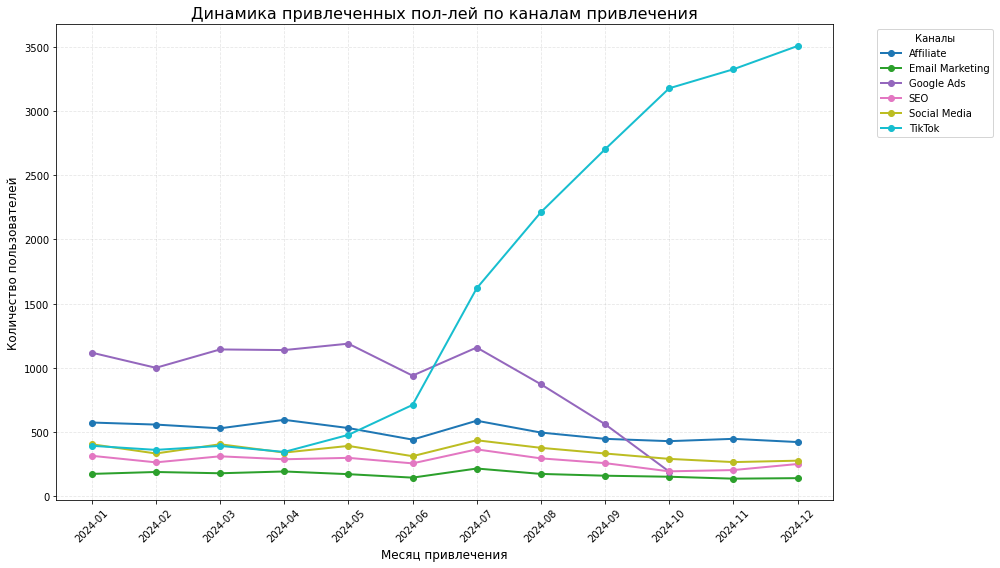

In [25]:
# РАСЧЕТ ПРИВЛЕЧЕННЫХ ПОЛ-ЛЕЙ КАНАЛАМ И МЕСЯЦАМ
users_active_month = pa_marketplace_users.copy()

# MAU по каналам и месяцам привлечения
mau_data = users_active_month.groupby(['acq_channel', 'cohort_month'])['user_id'].nunique()
mau_df = mau_data.reset_index()
mau_df.columns = ['acq_channel', 'month', 'mau_count']

# Получаем список каналов
channels = mau_df['acq_channel'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(channels)))

# Сортируем месяцы
mau_df['month'] = pd.to_datetime(mau_df['month'])
mau_df = mau_df.sort_values(['acq_channel', 'month'])

# Строим график MAU
plt.figure(figsize=(14, 8))

for idx, channel in enumerate(channels):
    channel_data = mau_df[mau_df['acq_channel'] == channel]
    channel_data = channel_data.sort_values('month')
    plt.plot(channel_data['month'].dt.strftime('%Y-%m'), channel_data['mau_count'], 
             marker='o', linewidth=2, markersize=6, color=colors[idx],
             label=channel)

# Настраиваем график
plt.title('Динамика привлеченных пол-лей по каналам привлечения', fontsize=16)
plt.xlabel('Месяц привлечения', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Каналы', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

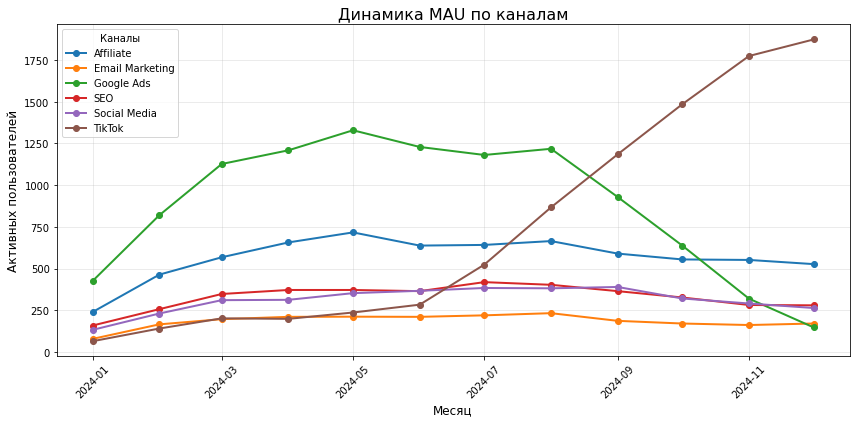

In [26]:
#расчет MAU
events_active = pa_marketplace_events.copy()
users_active = pa_marketplace_users.copy()

events_users = pd.merge(events_active, users_active, how='left', on='user_id')

# MAU по каналам и месяцам
mau_df = events_users.groupby(['acq_channel', 'event_month'])['user_id'].nunique().reset_index()
mau_df.columns = ['Канал', 'Месяц', 'Активных пользователей']

# Получаем каналы
channels = mau_df['Канал'].unique()

# Визуализация
plt.figure(figsize=(12, 6))

for channel in channels:
    channel_data = mau_df[mau_df['Канал'] == channel].sort_values('Месяц')
    plt.plot(channel_data['Месяц'], channel_data['Активных пользователей'], 
             marker='o', linewidth=2, label=channel)

plt.title('Динамика MAU по каналам', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Активных пользователей', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Каналы')
plt.tight_layout()


#### Промежуточный вывод
Рассмотрев каналы привлечения, можно увидеть, что наибольшую выручку приносят пол-ли, которые пришли с каналов "Googla Ads", "Affiliate". Именно они показали стремительный сезонный рост, но к сожалению выручка от канала "Googla Ads" к концу года упала до значений меньше 200 000, что меньше началогодовых значений, по каналу "Affiliate" показала среднее значение около 500 000.
По динамике затрат по каналам видно, что практически на все каналы бюджет распределен одинаково - около 200 000, лишь на 2-а канала увеличен бюджет: "Googla Ads" (около 600 000) и "TikTok" (увеличивается с 200 000 до 900 000). Но с июля есть большой спад в финансировании канала "Googla Ads", в октябре финансировании канала совсем закончено.
По динамике привлеченных пол-лей видно увеличение по каналу "TikTok" (с 500 до 3500) и стабильно среднее кол-во пол-лей, которое приходит с канала "Googla Ads" (среднее 1000 - 1250, к концу года сильный спад), который заканчивается в октябре, остальные каналы показывают стабильный прирост пол-лей на уровне 200 - 400 пол-лей. 
При этом наиболее активные пол-ли приходят с каналов "Googla Ads" и "TikTok". 
Таким образом, можно сделать вывод о том, что самый перспективный канал по активным пол-лям и выручки с канала был - "Google_Ads", после снижения его финансирования резко уменьшилась общая выручка маркетплейса и продолжала падать. Увеличение маркетингового бюджета на канал "TikTok" показал хороший прирост активных пол-лей, но к сожаелнию, это пол-ли средний чек которых довольно низкий.

No handles with labels found to put in legend.


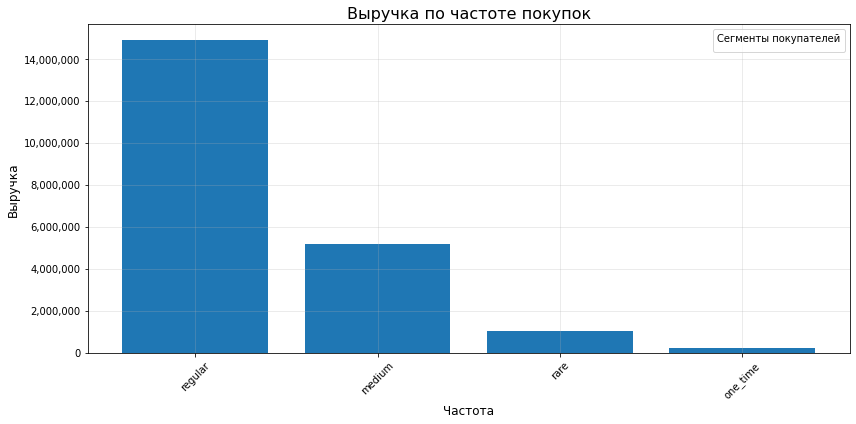

In [27]:
orders_users_copy = orders_users.copy()

orders_users_copy['revenue'] = orders_users_copy['total_price']*0.05
orders_users_group = orders_users_copy.groupby('buyer_segment')['revenue'].sum().reset_index()
orders_users_group = orders_users_group.sort_values('revenue', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(orders_users_group['buyer_segment'], orders_users_group['revenue'])
plt.title('Выручка по частоте покупок', fontsize=16)
plt.xlabel('Частота', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Форматируем ось Y для больших чисел
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.legend(title='Сегменты покупателей')
plt.tight_layout()
plt.show()

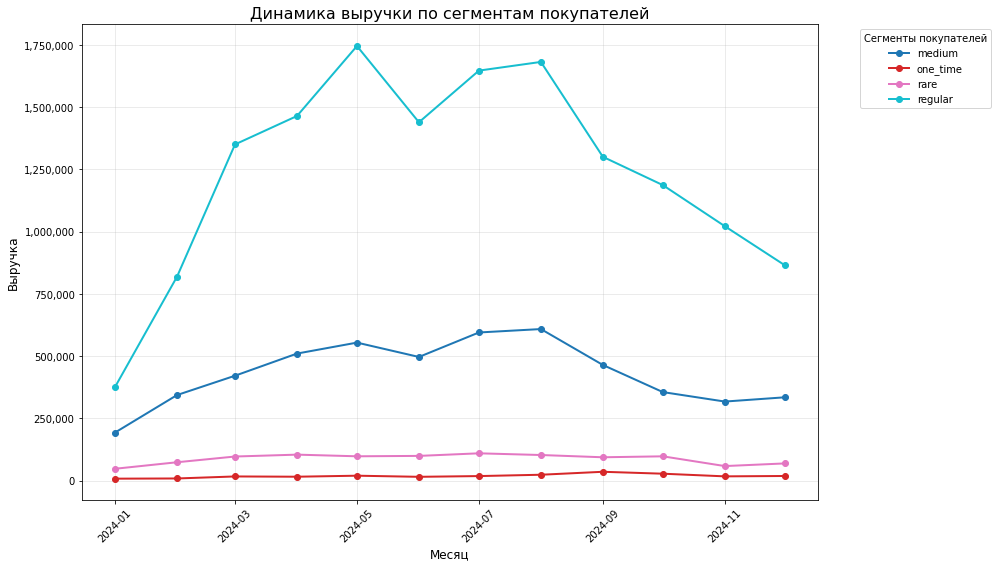

In [28]:
orders_users_copy = orders_users.copy()

orders_users_copy['revenue'] = orders_users_copy['total_price'] * 0.05
orders_users_group = orders_users_copy.groupby(['buyer_segment', 'order_month'])['revenue'].sum().reset_index()

# Получаем уникальные сегменты
segments = orders_users_group['buyer_segment'].unique()

# Визуализация
plt.figure(figsize=(14, 8))

# Создаем цветовую палитру
colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))

for idx, s in enumerate(segments):
    segment_data = orders_users_group[orders_users_group['buyer_segment'] == s].sort_values('order_month')
    plt.plot(segment_data['order_month'], segment_data['revenue'],
             marker='o', linewidth=2, 
             color=colors[idx],
             label=s)

plt.title('Динамика выручки по сегментам покупателей', fontsize=16)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Форматируем ось Y для больших чисел
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.legend(title='Сегменты покупателей', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Промежуточный вывод
Динамика выручка по сегментам пок-лей показала нам, что основная часть пол-лей делает покупки регулярно. Результаты показывают удовлетворенность пол-лей в общем маркетплейсом. У них есть мотивация заходить именно на это МК снова и делать покупки.

,category_name,revenue
11,Мебель для дома,3580998.22
2,Бытовая техника,2248933.06
24,Украшения и часы,1718297.10
18,Спортивный инвентарь,1165361.15
23,Товары для туризма,1137317.79


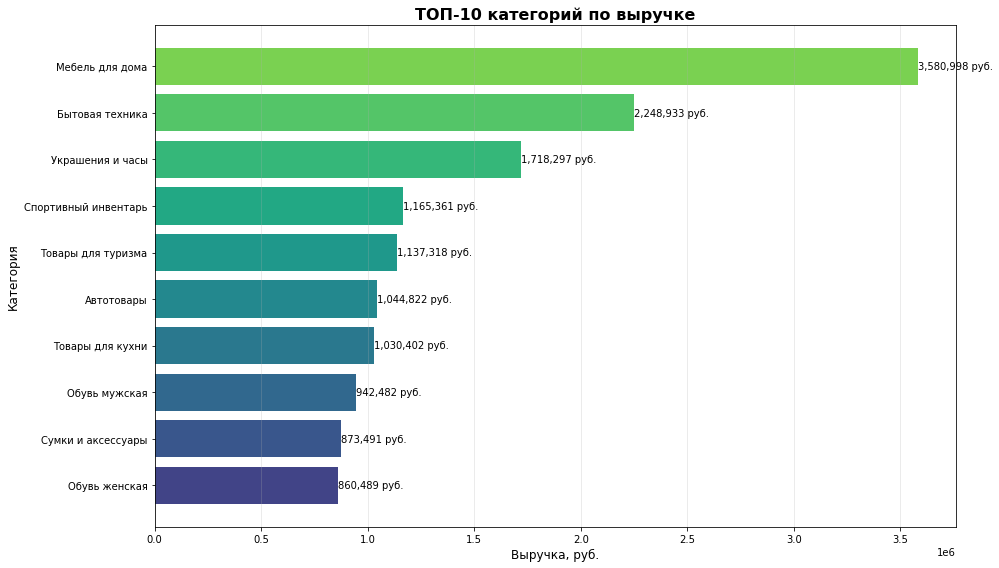

In [29]:
orders_users_copy = orders_users.copy()

orders_users_copy['revenue'] = orders_users_copy['total_price'] * 0.05

# Общая выручка по категориям (без учета сегментов)
category_revenue_total = orders_users_copy.groupby('category_name')['revenue'].sum().reset_index()
category_revenue_total = category_revenue_total.sort_values('revenue', ascending=False)
display(category_revenue_total.head(5))
# Визуализация
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 10))

bars = plt.barh(category_revenue_total['category_name'].head(10)[::-1], 
                category_revenue_total['revenue'].head(10)[::-1], 
                color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'{width:,.0f} руб.', 
             ha='left', va='center', fontsize=10)

plt.title('ТОП-10 категорий по выручке', fontsize=16, fontweight='bold')
plt.xlabel('Выручка, руб.', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# Анализ по сегментам покупателей
orders_users_group = orders_users_copy.groupby(['buyer_segment', 'category_name'])['revenue'].sum().reset_index()

# Для каждого сегмента находим топ-3 категории
top_categories_by_segment = orders_users_group.sort_values(['buyer_segment', 'revenue'], ascending=[True, False])

# Группируем по сегментам и берем топ-3
top_categories_by_segment = top_categories_by_segment.groupby('buyer_segment').head(3)

print("ТОП-3 категории по выручке для каждого сегмента:")
display(top_categories_by_segment)

ТОП-3 категории по выручке для каждого сегмента:


,buyer_segment,category_name,revenue
11,medium,Мебель для дома,812089.20
2,medium,Бытовая техника,504759.42
24,medium,Украшения и часы,399260.79
36,one_time,Мебель для дома,32334.40
27,one_time,Бытовая техника,26266.10
25,one_time,Автотовары,15782.21
61,rare,Мебель для дома,144519.22
52,rare,Бытовая техника,121820.76
68,rare,Спортивный инвентарь,69603.17
86,regular,Мебель для дома,2484039.89


#### Промежуточный вывод
Самые прибыльные категории покупок: мебель для дома, бытовая техника, украшения и часы, спортивный инвентарь, товары для туризма.

No handles with labels found to put in legend.


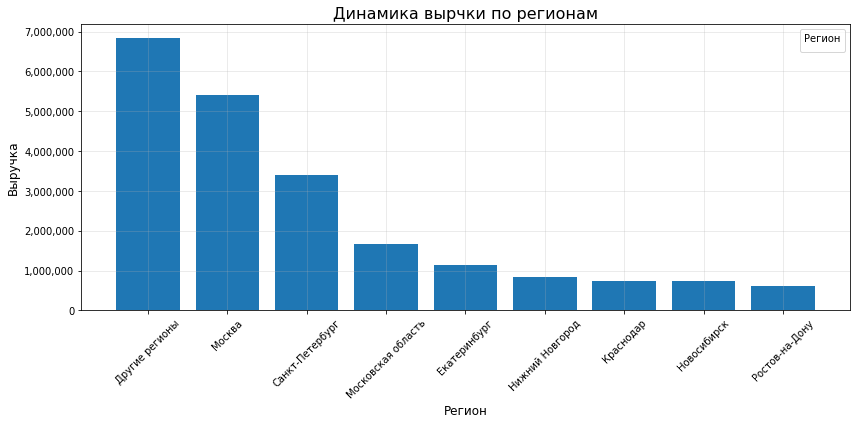

In [31]:
orders_users_copy = orders_users.copy()

orders_users_copy['revenue'] = orders_users_copy['total_price']*0.05
orders_users_group = orders_users_copy.groupby('region')['revenue'].sum().reset_index()
orders_users_group = orders_users_group.sort_values('revenue', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(orders_users_group['region'], orders_users_group['revenue'])

plt.title('Динамика вырчки по регионам', fontsize=16)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Форматируем ось Y для больших чисел
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.legend(title='Регион')
plt.tight_layout()
plt.show()

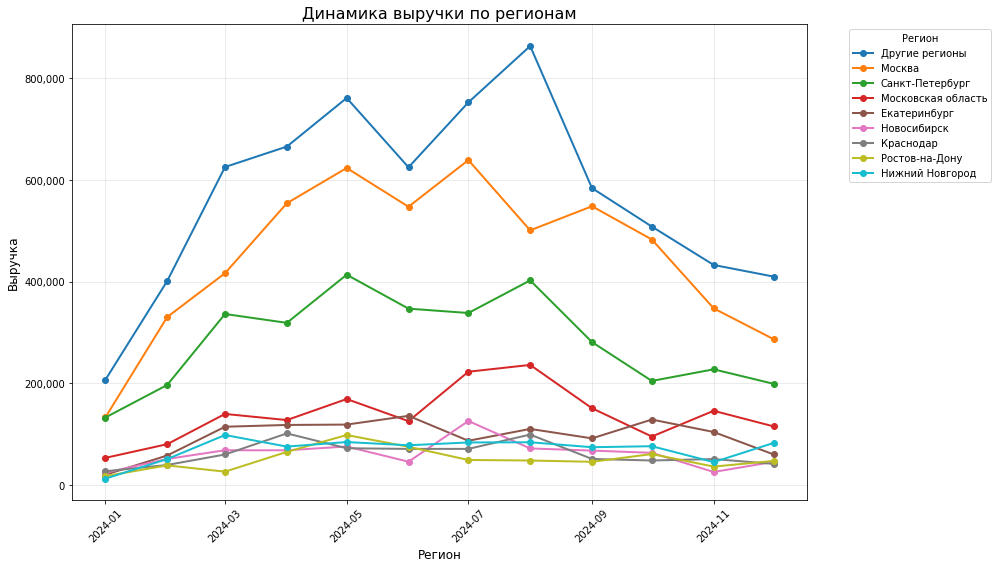

In [32]:
orders_users_copy = orders_users.copy()

orders_users_copy['revenue'] = orders_users_copy['total_price']*0.05
orders_users_group = orders_users_copy.groupby(['region', 'order_month'])['revenue'].sum().reset_index()
orders_users_group = orders_users_group.sort_values('revenue', ascending=False)

# Получаем уникальные сегменты
segments = orders_users_group['region'].unique()

# Визуализация
plt.figure(figsize=(14, 8))

# Создаем цветовую палитру
colors = plt.cm.tab10(np.linspace(0, 1, len(segments)))

for idx, s in enumerate(segments):
    segment_data = orders_users_group[orders_users_group['region'] == s].sort_values('order_month')
    plt.plot(segment_data['order_month'], segment_data['revenue'],
             marker='o', linewidth=2, 
             color=colors[idx],
             label=s)

plt.title('Динамика выручки по регионам', fontsize=16)
plt.xlabel('Регион', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Форматируем ось Y для больших чисел
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.legend(title='Регион', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Выводы по этапу 4

Что касается пользовательского пути на площадке маркетплейса. Оформление заказа эффективно: 82.87% начавших оформление завершают его. Процесс покупки отлажен: пользователям легко пройти от корзины до оформления заказа.Нет технических проблем на поздних этапах. По классической воронке видно, что мы теряем 37% посетителей до оформления заказа. Посетители смотрят товары, но не покупают.

Закономерности между уменьшением выручки и использование различных типой устройств и операционных систем не выявлено.
Рассмотрев каналы привлечения, можно увидеть, что наибольшую выручку приносят пол-ли, которые пришли с каналов "Googla Ads", "Affiliate". Именно они показали стремительный сезонный рост, но к сожалению выручка от канала "Googla Ads" к концу года упала до значений меньше 200 000, что меньше началогодовых значений, по каналу "Affiliate" показала среднее значение около 500 000. По динамике затрат по каналам видно, что практически на все каналы бюджет распределен одинаково - около 200 000, лишь на 2-а канала увеличен бюджет: "Googla Ads" (около 600 000) и "TikTok" (увеличивается с 200 000 до 900 000). Но с июля есть большой спад в финансировании канала "Googla Ads", в октябре финансировании канала совсем закончено. По динамике привлеченных пол-лей видно увеличение по каналу "TikTok" (с 500 до 3500) и стабильно среднее кол-во пол-лей, которое приходит с канала "Googla Ads" (среднее 1000 - 1250, к концу года сильный спад), который заканчивается в октябре, остальные каналы показывают стабильный прирост пол-лей на уровне 200 - 400 пол-лей. При этом наиболее активные пол-ли приходят с каналов "Googla Ads" и "TikTok". Таким образом, можно сделать вывод о том, что самый перспективный канал по активным пол-лям и выручки с канала был - "Google_Ads", после снижения его финансирования резко уменьшилась общая выручка маркетплейса и продолжала падать. Увеличение маркетингового бюджета на канал "TikTok" показал хороший прирост активных пол-лей, но к сожаелнию, это пол-ли средний чек которых довольно низкий.

Самые прибыльные категории покупок: мебель для дома, бытовая техника, украшения и часы, спортивный инвентарь, товары для туризма. Самые прибыльные региона - Москва, СПб, что вполне логично.

Главной и явной стратегией здесь будет изменение маркетинговой политики и перераспределение маркетингового бюджета по каналам. Стоит уменьшить бюджет на канал "TikTok" и увеличить снова на "GoogleAds", тк он демонстрировал хорошие показатели прибыли и активных пользователей одновременно.
С точки зрения пользовательского пути верным решением будет изменение страницы оформления заказа, возникает ощущение, что при ее заполнении у части пол-лей есть проблемы.
Учитывая, что большая часть пол-лей делает пратически регулярно, стоит обратить внимание на пол-лей, которые сделали покупку один раз и привлечь их рассылкой промокда со скидкой, чтобы была мотивация воспользоваться сервисом повторно.

## 5. Подготовка эксперимента и подведение его результатов

# Новые вводные

После рассмотрения гипотез командой принято решений влиять на конверсию при помощи финансовых стимуляций. 

## Новые данные:

```python
pa_diploma_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv')
pa_diploma_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv')
pa_diploma_sessions_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv')
pa_diploma_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv')
```

## Результаты сплита в таблице:

```python
pa_diploma_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')
```

* user_id – id клиента
* group – группа, в которую попал клиент

Таблицы с данными о пользователях, событиях и заказах идентичны таблицам с историческими данными.

Описание таблицы `sessions_AB` :

- session_id - уникальный идентификатор сессии;
- user_id - уникальный идентификатор пользователя;
- session_start - дата и время начала сессии;
- os - операционная система устройства;
- device - тип устройства;
- region - регион пользователя;
- browser - браузер, используемый пользователем;
- country - страна пользователя;
- entry_path - путь входа (начальная страница сессии);
- path_start - путь начала отслеживания;
- utm_source - ;
- screen_size - разрешение экрана устройства;
- scroll_depth - глубина прокрутки;
- user_segment - сегмент пользователя (regular/premium и т.д.);
- utm_campaign_id - идентификатор рекламной кампании;
- session_week - неделя сессии;
- session_month - месяц сессии.

# Дизайн эксперимента:

Бонус на первую покупку для пользователей TikTok

## 1. Контекст и цель эксперимента

- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.  
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.  
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку

---

## 2. Формат эксперимента

- **Тип эксперимента:** Сплит-роллинг (rolling split)  
- **Канал:** Только пользователи, пришедшие с TikTok  
- **Группы:**  
  - **Контрольная (A):** пользователи TikTok без бонуса  
  - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку  
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации  
- **Период проведения:** 3 недели (фиксировано)

---

## 3. Ключевые метрики

### Основная метрика

- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку  
  - *Цель:* увеличить конверсию с помощью бонуса  
  - *Критерий успеха:* статистически значимый рост конверсии в тестовой группе

### Вспомогательные метрики

- **ARPU** (средняя выручка на пользователя TikTok)  
- **ARPPU** (средняя выручка на покупателя TikTok)  
- **AOV** (средний чек TikTok)

### Барьерная метрика

- **Общая выручка от пользователей TikTok**

---

## 4. Размеры групп и запуск

- **Целевая аудитория:** только пользователи TikTok  
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента  
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


In [33]:
pa_diploma_events_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_events_AB.csv', parse_dates=['event_date', 'event_week', 'event_month'])
pa_diploma_orders_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_orders_AB.csv', parse_dates=['order_date', 'order_week', 'order_month'])
pa_diploma_sessions_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_sessions_AB.csv', parse_dates=['session_start', 'session_week', 'session_month'])
pa_diploma_users_AB = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_users_AB.csv', parse_dates=['registration_date', 'cohort_week', 'cohort_month'])
pa_diploma_AB_split_users = pd.read_csv('https://code.s3.yandex.net/datasets/pa_diploma_AB_split_users.csv')

In [34]:
display(pa_diploma_events_AB.head(5))
print(f" Мин дата события {pa_diploma_events_AB['event_date'].min()}")
print(f" Макс дата события {pa_diploma_events_AB['event_date'].max()}", sep="\n\n")
pa_diploma_events_AB.info()

,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01


 Мин дата события 2024-01-01 15:23:56
 Макс дата события 2025-01-26 23:59:34
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   session_id    831231 non-null  int64         
 2   user_id       831231 non-null  int64         
 3   event_date    831231 non-null  datetime64[ns]
 4   event_type    831231 non-null  object        
 5   os            831231 non-null  object        
 6   device        831231 non-null  object        
 7   event_index   831231 non-null  int64         
 8   user_segment  831231 non-null  object        
 9   product_name  409054 non-null  object        
 10  event_week    831231 non-null  datetime64[ns]
 11  event_month   831231 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(4), object(5)
memory usage: 76.1+ MB


In [35]:
#проверка дубликатов
print(pa_diploma_events_AB['event_type'].unique())
print(pa_diploma_events_AB['os'].unique())
print(pa_diploma_events_AB['device'].unique())
print(pa_diploma_events_AB['user_segment'].unique())
print(pa_diploma_events_AB['product_name'].unique())
print(pa_diploma_events_AB.duplicated().sum())

['page_view' 'product_view' 'product_click' 'add_to_cart' 'checkout_start'
 'checkout_complete' 'user_logout' 'search' 'category_view' 'filter_apply'
 'promo_view' 'wishlist_add' 'user_login' 'banner_click'
 'remove_from_cart']
['iOS' 'Windows' 'macOS' 'Android']
['mobile' 'desktop' 'tablet']
['regular' 'rare' 'medium' 'one_time']
[nan 'Шорты для тренировок' 'Куртка детская' 'Балетки классические'
 'Маска для лица' 'Одеяло детское' 'Поло Ralph Lauren' 'Брюки палаццо'
 'Зубная паста' 'Коврик для йоги' 'Фен для волос' 'Гречка ядрица'
 'Пальто зимнее' 'Тушь для ресниц' 'Горелка газовая' 'Сумка кожаная'
 'Доска разделочная' 'Свитер с капюшоном' 'Шуруповерт' 'Часы Casio'
 'Коляска трансформер' 'Анкер PowerBank' 'Мяч футбольный'
 'Пластырь медицинский' 'Маркеры цветные' 'Spigen чехол' 'Чай черный'
 'Гель для душа' 'Спальный мешок' 'Запонки классические'
 'Перчатки кожаные' 'Конструктор LEGO' 'Лежак для питомца'
 'Костюм спортивный' 'Компас туристический' 'Духи Chanel'
 'Берцы тактические' 'С

In [36]:
display(pa_diploma_orders_AB.head(5))
print(f" Мин дата события {pa_diploma_orders_AB['order_date'].min()}")
print(f" Макс дата события {pa_diploma_orders_AB['order_date'].max()}", sep="\n\n")
pa_diploma_orders_AB.info()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


 Мин дата события 2024-01-01 08:03:45
 Макс дата события 2025-01-26 23:07:50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  datetime64[ns]
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.5+ MB


In [37]:
#проверка дубликатов
print(pa_diploma_orders_AB['product_name'].unique())
print(pa_diploma_orders_AB['category_name'].unique())
print(pa_diploma_orders_AB.duplicated().sum())

['Шуруповерт' 'Молоток слесарный' 'Секатор садовый' 'Чай черный'
 'Грабли веерные' 'Джинсы скинни' 'Xiaomi Mi Band' 'Толстовка с капюшоном'
 'Часы настенные' 'Baseus зарядка' 'Пальто зимнее' 'Брюки палаццо'
 'Майка борцовка' 'Светильник настольный' 'Отвертки набор'
 'Футболка принт' 'Костюм спортивный' 'Ваза керамическая'
 'Настольная игра' 'Самокат трехколесный' 'Зеркало в раме' 'Тетрадь общая'
 'Люстра хрустальная' 'Глюкометр' 'Помада матовая' 'Кардиган вязаный'
 'Термос стальной' 'Спальный мешок' 'Масло подсолнечное' 'Гречка ядрица'
 'Колготки детские' 'Свитер с капюшоном' 'Рюкзак городской'
 'Перчатки кожаные' 'Чехлы на сиденья' 'Свечи ароматические'
 'Машинка радиоуправляемая' 'Туфли оксфорд' 'Кроссовки белые'
 'Мокасины кожаные' 'Маска для волос' 'Сандалии летние' 'Роман бестселлер'
 'Духи Chanel' 'Свитер шерстяной' 'Лак для ногтей' 'Ремень кожаный'
 'Ботинки классические' 'Мука пшеничная' 'Костюм для мальчика'
 'Балетки классические' 'Пиджак casual' "Джинсы Levi's" 'Крем для лиц

In [38]:
display(pa_diploma_sessions_AB.head(5))
print(f" Мин дата события {pa_diploma_sessions_AB['session_start'].min()}")
print(f" Макс дата события {pa_diploma_sessions_AB['session_start'].max()}", sep="\n\n")
pa_diploma_sessions_AB.info()

,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month
0,705,160,2024-01-12 02:30:37,Windows,mobile,Москва,Safari,Россия,/home,/recommend/10,unknown,768x1024,51,regular,14.00,2024-01-08,2024-01-01
1,706,160,2024-01-10 06:04:41,Windows,mobile,Москва,Safari,Россия,/home,/sale/2,unknown,375x667,71,regular,14.00,2024-01-08,2024-01-01
2,707,160,2024-01-23 03:31:16,Windows,mobile,Москва,Safari,Россия,/checkout,/click/20,unknown,768x1024,84,regular,14.00,2024-01-22,2024-01-01
3,708,160,2024-01-18 13:43:45,Windows,mobile,Москва,Safari,Россия,/category,/campaign/20,unknown,768x1024,20,regular,14.00,2024-01-15,2024-01-01
4,709,160,2024-01-21 01:09:58,Windows,mobile,Москва,Safari,Россия,/promo,/sale/3,unknown,1366x768,88,regular,14.00,2024-01-15,2024-01-01


 Мин дата события 2024-01-01 08:34:27
 Макс дата события 2025-01-26 23:58:24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127407 entries, 0 to 127406
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   session_id       127407 non-null  int64         
 1   user_id          127407 non-null  int64         
 2   session_start    127407 non-null  datetime64[ns]
 3   os               127407 non-null  object        
 4   device           127407 non-null  object        
 5   region           127407 non-null  object        
 6   browser          127407 non-null  object        
 7   country          127407 non-null  object        
 8   entry_path       127407 non-null  object        
 9   path_start       127407 non-null  object        
 10  utm_source       127407 non-null  object        
 11  screen_size      127407 non-null  object        
 12  scroll_depth     127407 non-null  int64         
 1

In [39]:
#проверка дубликатов
print(pa_diploma_sessions_AB['os'].unique())
print(pa_diploma_sessions_AB['device'].unique())
print(pa_diploma_sessions_AB['region'].unique())
print(pa_diploma_sessions_AB['browser'].unique())
print(pa_diploma_sessions_AB['country'].unique())
print(pa_diploma_sessions_AB['entry_path'].unique())
print(pa_diploma_sessions_AB['path_start'].unique())
print(pa_diploma_sessions_AB['utm_source'].unique())
print(pa_diploma_sessions_AB['screen_size'].unique())
print(pa_diploma_sessions_AB['user_segment'].unique())
print(pa_diploma_sessions_AB.duplicated().sum())

['Windows' 'macOS' 'Android' 'iOS']
['mobile' 'tablet' 'desktop']
['Москва' 'Московская область' 'Другие регионы' 'Краснодар' 'Новосибирск'
 'Санкт-Петербург' 'Нижний Новгород' 'Екатеринбург' 'Ростов-на-Дону']
['Safari' 'Firefox' 'Chrome' 'Edge']
['Россия']
['/home' '/checkout' '/category' '/promo' '/product']
['/recommend/10' '/sale/2' '/click/20' '/campaign/20' '/sale/3' '/sale/19'
 '/recommend/2' '/click/8' '/recommend/8' '/recommend/1' '/recommend/7'
 '/recommend/5' '/campaign/13' '/recommend/15' '/click/18' '/recommend/6'
 '/campaign/14' '/recommend/19' '/campaign/11' '/sale/4' '/campaign/5'
 '/recommend/20' '/recommend/16' '/click/11' '/campaign/8' '/campaign/15'
 '/campaign/9' '/click/7' '/sale/7' '/campaign/12' '/recommend/17'
 '/campaign/7' '/campaign/4' '/sale/13' '/sale/8' '/recommend/4'
 '/sale/11' '/sale/12' '/recommend/9' '/campaign/2' '/recommend/12'
 '/sale/9' '/click/9' '/click/13' '/click/17' '/sale/18' '/click/2'
 '/click/1' '/campaign/6' '/campaign/16' '/campaign/19

In [40]:
display(pa_diploma_users_AB.head(5))
print(f" Мин дата события {pa_diploma_users_AB['registration_date'].min()}")
print(f" Макс дата события {pa_diploma_users_AB['registration_date'].max()}", sep="\n\n")
pa_diploma_users_AB.info()

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.00,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.00,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.00,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.00,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.00,спящий,rare,2024-01-01,2024-01-01


 Мин дата события 2024-01-01 01:13:00
 Макс дата события 2025-01-26 23:41:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   os                 22196 non-null  object        
 3   age                22196 non-null  int64         
 4   device             22196 non-null  object        
 5   gender             22196 non-null  object        
 6   region             22196 non-null  object        
 7   browser            22196 non-null  object        
 8   country            22196 non-null  object        
 9   acq_channel        22196 non-null  object        
 10  campaign_id        22196 non-null  float64       
 11  user_segment       22196 non-null  object        
 12  buyer_segment      22196 non-null  obje

In [41]:
#проверка дубликатов
print(pa_diploma_users_AB['os'].unique())
print(pa_diploma_users_AB['gender'].unique())
print(pa_diploma_users_AB['device'].unique())
print(pa_diploma_users_AB['region'].unique())
print(pa_diploma_users_AB['browser'].unique())
print(pa_diploma_users_AB['country'].unique())
print(pa_diploma_users_AB['acq_channel'].unique())
print(pa_diploma_users_AB['user_segment'].unique())
print(pa_diploma_users_AB['buyer_segment'].unique())
print(pa_diploma_sessions_AB.duplicated().sum())

['Android' 'iOS' 'Windows' 'macOS']
['M' 'F']
['mobile' 'tablet' 'desktop']
['Екатеринбург' 'Санкт-Петербург' 'Москва' 'Другие регионы'
 'Ростов-на-Дону' 'Московская область' 'Нижний Новгород' 'Новосибирск'
 'Краснодар']
['Edge' 'Chrome' 'Firefox' 'Safari']
['Россия']
['TikTok']
['спящий' 'VIP' 'активный' 'новичок']
['one_time' 'rare' 'medium' 'regular']
0


In [42]:
display(pa_diploma_AB_split_users.head(5))
pa_diploma_AB_split_users.info()

,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


In [43]:
#объединим таблицу splt_users и events
groups_users = pd.merge(pa_diploma_AB_split_users, pa_diploma_users_AB[['registration_date', 'user_id']], how='left', on='user_id')
group_users_events = pd.merge(groups_users, pa_diploma_events_AB, how='left', on='user_id')
df = pd.merge(group_users_events, pa_diploma_orders_AB, how='left', on='user_id')
display(df.head(15))
print(f" Мин дата события {df['event_date'].min()}")
print(f" Макс дата события {df['event_date'].max()}", sep="\n\n")
df.info()
df = df.fillna(0)

,user_id,group,registration_date,event_id,session_id,event_date,event_type,os,device,event_index,...,event_month,order_id,order_date,product_name_y,quantity,unit_price,total_price,category_name,order_week,order_month
0,44965,control,2025-01-01 18:10:00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,44967,control,2025-01-01 11:29:00,843550.00,135182.00,2025-01-17 19:32:26,page_view,iOS,tablet,1.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
2,44967,control,2025-01-01 11:29:00,843551.00,135182.00,2025-01-17 19:33:25,product_view,iOS,tablet,2.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
3,44967,control,2025-01-01 11:29:00,843552.00,135182.00,2025-01-17 19:33:55,product_click,iOS,tablet,3.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
4,44967,control,2025-01-01 11:29:00,843553.00,135182.00,2025-01-17 19:34:23,add_to_cart,iOS,tablet,4.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
5,44967,control,2025-01-01 11:29:00,843554.00,135182.00,2025-01-17 19:34:54,checkout_start,iOS,tablet,5.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
6,44967,control,2025-01-01 11:29:00,843555.00,135182.00,2025-01-17 19:35:32,checkout_complete,iOS,tablet,6.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
7,44967,control,2025-01-01 11:29:00,843556.00,135182.00,2025-01-17 19:36:27,category_view,iOS,tablet,7.00,...,2025-01-01,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
8,44968,control,2025-01-01 13:05:00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT
9,44969,treatment,2025-01-01 00:23:00,NaN,NaN,NaT,NaN,NaN,NaN,NaN,...,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT


 Мин дата события 2025-01-02 03:25:32
 Макс дата события 2025-01-26 23:46:15
<class 'pandas.core.frame.DataFrame'>
Int64Index: 7507 entries, 0 to 7506
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            7507 non-null   int64         
 1   group              7507 non-null   object        
 2   registration_date  7507 non-null   datetime64[ns]
 3   event_id           4958 non-null   float64       
 4   session_id         4958 non-null   float64       
 5   event_date         4958 non-null   datetime64[ns]
 6   event_type         4958 non-null   object        
 7   os                 4958 non-null   object        
 8   device             4958 non-null   object        
 9   event_index        4958 non-null   float64       
 10  user_segment       4958 non-null   object        
 11  product_name_x     2664 non-null   object        
 12  event_week         4958 non-null   dateti

In [44]:
#проверим пересечение в группах
df = df.copy()
count_groups = df.groupby('user_id')['group'].nunique().reset_index()
group = count_groups[count_groups['group'] > 1]
display(group)

,user_id,group


- H0: конверсия в покупку не изменится при предоставлении бонуса на первую покупку.
- Н1: конверсия в покупку изменится при предоставлении бонуса на первую покупкую

In [45]:
#рассчитаем ключевую метрику в контрольной группе
df_control = df[df['group'] == 'control']
registr_users_control = df_control['user_id'].nunique()
paying_df_control = df_control[df_control['total_price'] > 0]
paying_users_control = paying_df_control['user_id'].nunique()
key_control = paying_users_control/registr_users_control*100

#рассчитаем ключевую метрику в тестовой группе
df_test = df[df['group'] == 'treatment'].copy()
registr_users_test = df_test['user_id'].nunique()
paying_df_test = df_test[df_test['total_price'] > 0]
paying_users_test = paying_df_test['user_id'].nunique()
key_test = paying_users_test/registr_users_test*100

# Используем Z-тест:
z_stat, p_value = proportions_ztest(
    [paying_users_control, paying_users_test],
    [registr_users_control, registr_users_test])

print(f"Конверсия контроль: {key_control}%")
print(f"Конверсия тест: {key_test}%")
print(f"P-value: {p_value:.20f}")
print(f"Значимо: {p_value < 0.05}")

# Рассчитаем абсолютное и относительное изменение
absolute_change = key_test - key_control
relative_change = (key_test / key_control - 1) * 100

print(f"\nАбсолютное изменение: {absolute_change:.4f}%")
print(f"Относительное изменение: {relative_change:.4f}%")

Конверсия контроль: 1.0645375914836992%
Конверсия тест: 7.508532423208192%
P-value: 0.00000000000000000316
Значимо: True

Абсолютное изменение: 6.4440%
Относительное изменение: 605.3328%


Уникальных недель когорт: 4
Диапазон недель: 2024-12-30 00:00:00 - 2025-01-20 00:00:00


conversion_rate           paying_users            \
group                     control treatment      control treatment   
registration_week                                                    
2024-12-30                   2.53     10.53            8        36   
2025-01-06                   0.77      9.55            3        36   
2025-01-13                   0.53      7.98            2        32   
2025-01-20                   0.71      1.74            3         6   

                  total_users            
group                 control treatment  
registration_week                        
2024-12-30                316       342  
2025-01-06                389       377  
2025-01-13                376       401  
2025-01-20                422       345

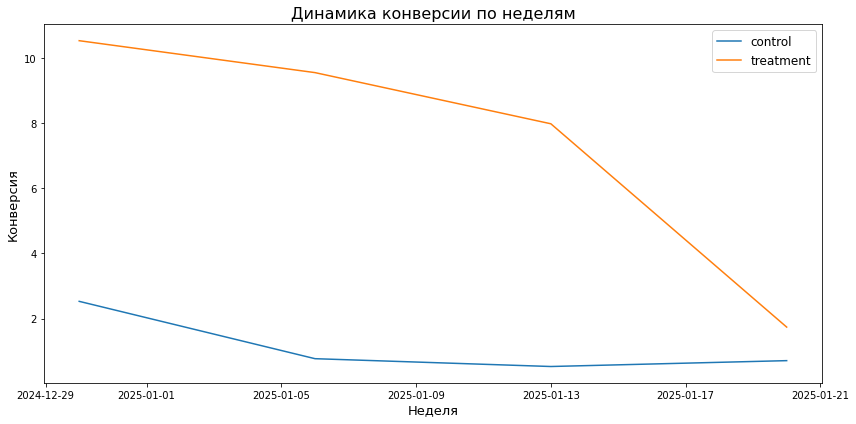

In [46]:
# Преобразуем registration_date в datetime
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')

# Создаем недельные когорты из registration_date
df['registration_week'] = df['registration_date'].dt.to_period('W').dt.start_time

# Проверяем результат
print(f"Уникальных недель когорт: {df['registration_week'].nunique()}")
print(f"Диапазон недель: {df['registration_week'].min()} - {df['registration_week'].max()}")

# Анализ конверсии по неделям и группам
weekly_analysis = df.groupby(['registration_week', 'group']).agg(
    total_users=('user_id', 'nunique'),
    paying_users=('user_id', lambda x: df.loc[df['user_id'].isin(x) & (df['total_price'] > 0), 'user_id'].nunique())).reset_index()

# Добавляем конверсию
weekly_analysis['conversion_rate'] = (weekly_analysis['paying_users'] / weekly_analysis['total_users'] * 100).round(2)

# Сортируем
weekly_analysis = weekly_analysis.sort_values(['registration_week', 'group'])


# Сводная таблица по неделям
weekly_pivot = weekly_analysis.pivot_table(
    index='registration_week',
    columns='group',
    values=['total_users', 'paying_users', 'conversion_rate'])

display(weekly_pivot)

plt.figure(figsize=(12, 6))

groups = weekly_analysis['group'].unique()

for g in groups:
    data = weekly_analysis[weekly_analysis['group'] == g]
    plt.plot(data['registration_week'], data['conversion_rate'], label=g)
plt.title('Динамика конверсии по неделям', fontsize=16)
plt.xlabel('Неделя', fontsize=13)
plt.ylabel('Конверсия', fontsize=13)
plt.tight_layout()
plt.legend(fontsize=12)

In [47]:
#РАСЧЕТ БАРЬЕРНОЙ МЕТРИКИ В КОНТРОЛЬНОЙ И ТЕСТОВОЙ ГРУППАХ
revenue_control = df_control['total_price'].sum()*0.05
revenue_test = df_test['total_price'].sum()*0.05

print(f"Выручка в контрольной группе: {revenue_control}")
print(f"Выручка в тестовой группе: {revenue_test}")

Выручка в контрольной группе: 107424.21149999998
Выручка в тестовой группе: 970650.0890000002


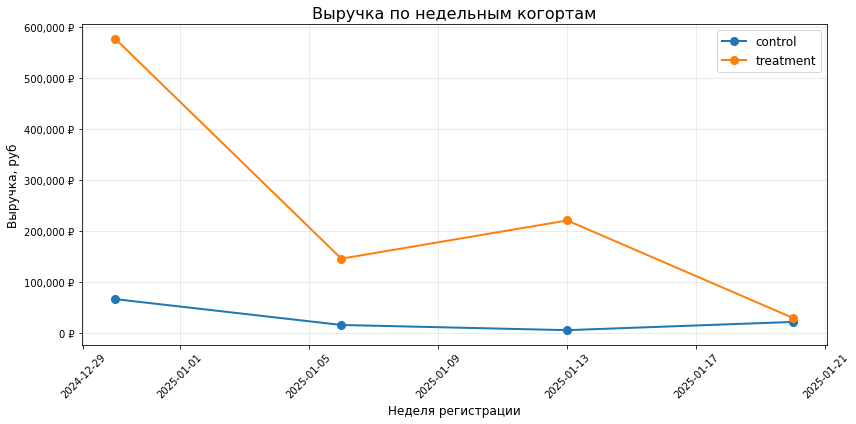

In [48]:
# Группируем по неделям и группам
weekly_revenue = df.groupby(['registration_week', 'group']).agg({
    'user_id': 'nunique',
    'total_price': lambda x: (x.sum() * 0.05)  }).reset_index()

weekly_revenue.columns = ['registration_week', 'group', 'total_users', 'revenue']

# ВИЗУАЛИЗАЦИЯ: Выручка по неделям
plt.figure(figsize=(12, 6))

for group in ['control', 'treatment']:
    mask = weekly_revenue['group'] == group
    data = weekly_revenue[mask].sort_values('registration_week')
    if not data.empty:
        plt.plot(data['registration_week'], data['revenue'], 
                label=group, marker='o', linewidth=2, markersize=8)

plt.title('Выручка по недельным когортам', fontsize=16)
plt.xlabel('Неделя регистрации', fontsize=12)
plt.ylabel('Выручка, руб', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Форматируем ось Y в рублях
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x:,.0f} ₽'))

plt.tight_layout()
plt.show()

In [49]:
#ВСПОМОГАТЕЛЬНЫЕ МЕТРИКИ В КОНТРОЛЬНОЙ ГРУППЕ
arpu_control = revenue_control/registr_users_control
arppu_control = revenue_control/paying_users_control
aov_control = revenue_control/df_control['order_id'].nunique()

#ВСПОМОГАТЕЛЬНЫЕ МЕТРИКИ В ТЕСТОВОЙ ГРУППЕ
arpu_test = revenue_test/registr_users_test
arppu_test = revenue_test/paying_users_test
aov_test = revenue_test/df_test['order_id'].nunique()

arpu_diff_abs = arpu_test - arpu_control
arppu_diff_abs = arppu_test - arppu_control
aov_diff_abs = aov_test - aov_control

arpu_diff = (arpu_test/arpu_control - 1) * 100
arppu_diff = (arppu_test/arppu_control - 1) * 100
aov_diff = (aov_test/aov_control - 1) * 100

# Создаем таблицу
metrics_data = {
    'Метрика': ['ARPU', 'ARPPU', 'AOV'],
    'Контроль': [arpu_control, arppu_control, aov_control],
    'Тест': [arpu_test, arppu_test, aov_test],
    'Абсолютное изменение': [arpu_diff_abs, arppu_diff_abs, aov_diff_abs],
    'Относительное изменение %': [arpu_diff, arppu_diff, aov_diff]}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Метрика,Контроль,Тест,Абсолютное изменение,Относительное изменение %
0,ARPU,71.47,662.56,591.09,827.00
1,ARPPU,6714.01,8824.09,2110.08,31.43
2,AOV,4296.97,4183.84,-113.13,-2.63


In [50]:
# Создаем колонку revenue
df_control['revenue'] = df_control['total_price'] * 0.05
df_test['revenue'] = df_test['total_price'] * 0.05

# Подготавливаем данные для тестов
# ARPU: доход на пользователя
arpu_control_data = df_control.groupby('user_id')['revenue'].sum().values
arpu_test_data = df_test.groupby('user_id')['revenue'].sum().values

# ARPPU: доход на платящего пользователя
arppu_control_data = df_control[df_control['revenue'] > 0].groupby('user_id')['revenue'].sum().values
arppu_test_data = df_test[df_test['revenue'] > 0].groupby('user_id')['revenue'].sum().values

# AOV: средний чек на заказ
aov_control_data = df_control.groupby('order_id')['revenue'].sum().values
aov_test_data = df_test.groupby('order_id')['revenue'].sum().values

# 3. Выполняем t-тесты
def quick_ttest(control, test, name):
    if len(control) < 2 or len(test) < 2:
        return {'p_value': np.nan, 'mean_diff': np.nan, 'rel_diff': np.nan}
    
    t_stat, p_val = ttest_ind(test, control, equal_var=False)
    mean_diff = np.mean(test) - np.mean(control)
    rel_diff = (mean_diff / np.mean(control)) * 100 if np.mean(control) != 0 else np.nan
    
    return {'p_value': p_val, 'mean_diff': mean_diff, 'rel_diff': rel_diff}

# Запускаем тесты для всех метрик
results = {
    'ARPU': quick_ttest(arpu_control_data, arpu_test_data, 'ARPU'),
    'ARPPU': quick_ttest(arppu_control_data, arppu_test_data, 'ARPPU'),
    'AOV': quick_ttest(aov_control_data, aov_test_data, 'AOV')}

# Создаем итоговую таблицу
summary_data = []
for metric, res in results.items():
    summary_data.append({
        'Метрика': metric,
        'p-value': res['p_value'],
        'Значимость': 'Да' if res['p_value'] < 0.05 else 'Нет',
        'Разница': res['mean_diff'],
        'Отн. разница %': res['rel_diff']})

summary_df = pd.DataFrame(summary_data)
display(summary_df)

for _, row in summary_df.iterrows():
    metric = row['Метрика']
    p_val = row['p-value']
    rel_diff = row['Отн. разница %']
    
    if pd.notna(p_val) and p_val < 0.05:
        if rel_diff > 0:
            print(f"✅ {metric}: УЛУЧШЕНИЕ на +{abs(rel_diff):.1f}% (p={p_val:.4f})")
        else:
            print(f"❌ {metric}: УХУДШЕНИЕ на -{abs(rel_diff):.1f}% (p={p_val:.4f})")
    elif pd.notna(p_val):
        print(f"➖ {metric}: {rel_diff:+.1f}% (незначимо, p={p_val:.4f})")
    else:
        print(f"⚠️  {metric}: недостаточно данных")

/tmp/ipykernel_197/1992457643.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_control['revenue'] = df_control['total_price'] * 0.05


,Метрика,p-value,Значимость,Разница,Отн. разница %
0,ARPU,0.00,Да,591.09,827.00
1,ARPPU,0.53,Нет,2110.08,31.43
2,AOV,0.94,Нет,-113.13,-2.63


✅ ARPU: УЛУЧШЕНИЕ на +827.0% (p=0.0013)
➖ ARPPU: +31.4% (незначимо, p=0.5318)
➖ AOV: -2.6% (незначимо, p=0.9444)


In [51]:
def quick_bootstrap(control, test, n_iterations=5000):
    if len(control) == 0 or len(test) == 0:
        return {'p_value': np.nan, 'mean_diff': np.nan, 'ci_lower': np.nan, 'ci_upper': np.nan}
    mean_diff = np.mean(test) - np.mean(control)
    bootstrap_diffs = []
    
    for _ in range(n_iterations):
        c_sample = np.random.choice(control, size=len(control), replace=True)
        t_sample = np.random.choice(test, size=len(test), replace=True)
        bootstrap_diffs.append(np.mean(t_sample) - np.mean(c_sample))
    
    # P-value
    if mean_diff > 0:
        p_value = 2 * (np.sum(np.array(bootstrap_diffs) <= 0) / n_iterations)
    else:
        p_value = 2 * (np.sum(np.array(bootstrap_diffs) >= 0) / n_iterations)
    
    # Confidence interval
    ci_lower = np.percentile(bootstrap_diffs, 2.5)
    ci_upper = np.percentile(bootstrap_diffs, 97.5)
    
    return {
        'p_value': p_value,
        'mean_diff': mean_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper}

quick_results = {
    'ARPU': quick_bootstrap(arpu_control_data, arpu_test_data),
    'ARPPU': quick_bootstrap(arppu_control_data, arppu_test_data),
    'AOV': quick_bootstrap(aov_control_data, aov_test_data)}

for metric, res in quick_results.items():
    p_val = res['p_value']
    if pd.notna(p_val):
        sign = "✅" if p_val < 0.05 and res['mean_diff'] > 0 else "❌" if p_val < 0.05 else "➖"
        print(f"{sign} {metric}: Разница = {res['mean_diff']:.2f}, "
              f"p = {p_val:.4f}, 95% ДИ = [{res['ci_lower']:.2f}, {res['ci_upper']:.2f}]")
    else:
        print(f"⚠️  {metric}: недостаточно данных")

✅ ARPU: Разница = 591.09, p = 0.0000, 95% ДИ = [279.51, 999.25]
➖ ARPPU: Разница = 2110.08, p = 0.5164, 95% ДИ = [-4453.43, 8522.53]
➖ AOV: Разница = -113.13, p = 0.9464, 95% ДИ = [-3337.21, 2995.09]


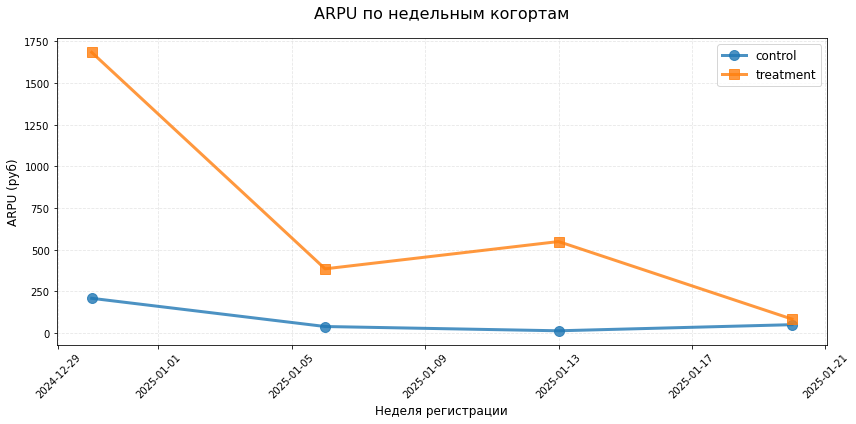

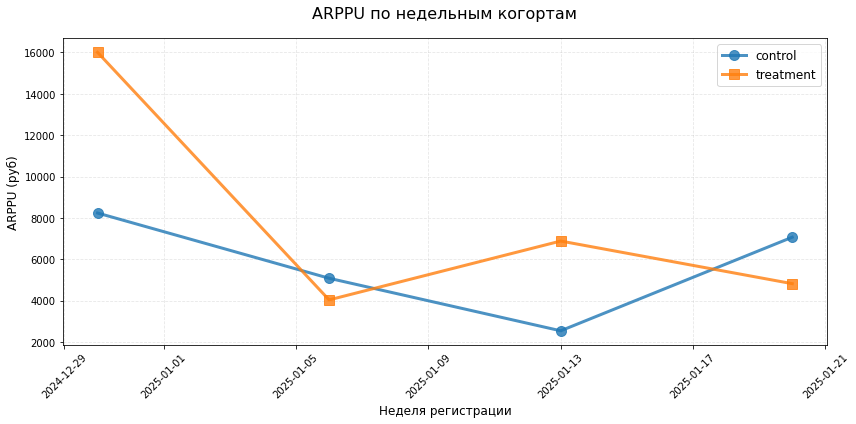

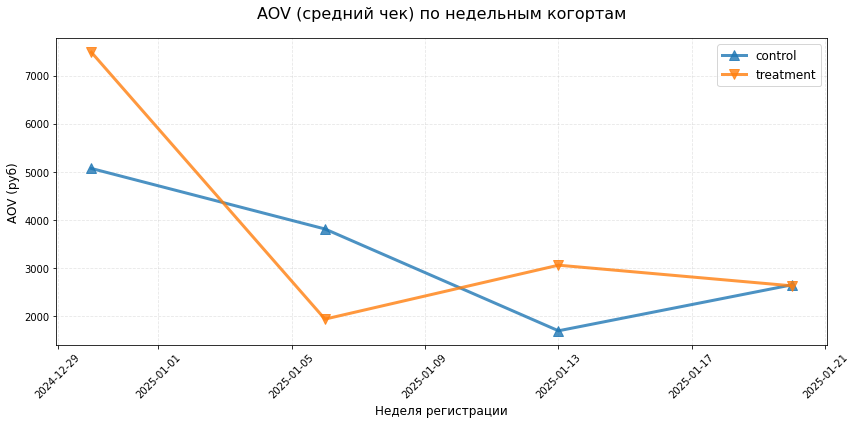

In [52]:
# Создаем DataFrame с недельными когортами
weekly_metrics = df.groupby(['registration_week', 'group']).agg({
    'user_id': 'nunique',
    'order_id': 'nunique',
    'total_price': lambda x: (x.sum() * 0.05)
}).reset_index()

weekly_metrics.columns = ['registration_week', 'group', 'total_users', 'total_orders', 'revenue']

# Добавляем платящих пользователей
paying_users = df[df['total_price'] > 0].groupby(['registration_week', 'group'])['user_id'].nunique().reset_index()
paying_users.columns = ['registration_week', 'group', 'paying_users']

weekly_metrics = weekly_metrics.merge(paying_users, on=['registration_week', 'group'], how='left')
weekly_metrics['paying_users'] = weekly_metrics['paying_users'].fillna(0)

# Рассчитываем метрики
weekly_metrics['arpu'] = weekly_metrics['revenue'] / weekly_metrics['total_users']
weekly_metrics['arppu'] = weekly_metrics['revenue'] / weekly_metrics['paying_users'].replace(0, np.nan)
weekly_metrics['aov'] = weekly_metrics['revenue'] / weekly_metrics['total_orders'].replace(0, np.nan)

# Сортируем
weekly_metrics = weekly_metrics.sort_values(['registration_week', 'group'])

# График ARPU по когортам
plt.figure(figsize=(12, 6))

colors = {'control': '#1f77b4', 'treatment': '#ff7f0e'}
markers = {'control': 'o', 'treatment': 's'}

for group in ['control', 'treatment']:
    mask = weekly_metrics['group'] == group
    data = weekly_metrics[mask].sort_values('registration_week')
    if not data.empty:
        plt.plot(data['registration_week'], data['arpu'], 
                label=group,
                color=colors[group],
                marker=markers[group],
                linewidth=3,
                markersize=10,
                alpha=0.8)

plt.title('ARPU по недельным когортам', fontsize=16, pad=20)
plt.xlabel('Неделя регистрации', fontsize=12)
plt.ylabel('ARPU (руб)', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График ARPPU по когортам
plt.figure(figsize=(12, 6))

for group in ['control', 'treatment']:
    mask = weekly_metrics['group'] == group
    data = weekly_metrics[mask].sort_values('registration_week')
    # Фильтруем только недели с платящими пользователями
    data = data[data['paying_users'] > 0]
    if not data.empty:
        plt.plot(data['registration_week'], data['arppu'], 
                label=group,
                color=colors[group],
                marker=markers[group],
                linewidth=3,
                markersize=10,
                alpha=0.8)

plt.title('ARPPU по недельным когортам', fontsize=16, pad=20)
plt.xlabel('Неделя регистрации', fontsize=12)
plt.ylabel('ARPPU (руб)', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График AOV по когортам
plt.figure(figsize=(12, 6))

for group in ['control', 'treatment']:
    mask = weekly_metrics['group'] == group
    data = weekly_metrics[mask].sort_values('registration_week')
    # Фильтруем только недели с заказами
    data = data[data['total_orders'] > 0]
    if not data.empty:
        plt.plot(data['registration_week'], data['aov'], 
                label=group,
                color=colors[group],
                marker='^' if group == 'control' else 'v',
                linewidth=3,
                markersize=10,
                alpha=0.8)

plt.title('AOV (средний чек) по недельным когортам', fontsize=16, pad=20)
plt.xlabel('Неделя регистрации', fontsize=12)
plt.ylabel('AOV (руб)', fontsize=12)
plt.legend(fontsize=12, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Выводы по этапу 5

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

Цель эксперимента: проверить есть ли различия в конверсии среди пользователей, привлеченных через канад TilTok. Для мотивации пользователей к покупке им предоставлялся бонус на первую покупку.

Гипотеза H0: конверсия в покупку не изменится при предоставлении бонуса на первую покупку.
Гипотеза Н1: конверсия в покупку изменится при предоставлении бонуса на первую покупкую.

AB тест продемонстрировал увеличение конверсии в тестовой группе на 6%. С помощью Z-теста это изменения зафиксировано статистически значимым, следовательно, применение бонуса на первую покупку оказало положительный эффект на пользователей. Но при этом стоит обратить внимание на то, что конверсия в начале эксперимента была на значении 10%, к концу эксперимента 1%. Данный  положительный эффект, затем падение свидетельствует о краткосрочности результатов, эффект может быть временным.
Стоит продлить тест и посмотреть на результаты изменения ключевой метрики.

Зафиксировано, что барьерная метрика не пострадала, к тому же, выручка в тестовой группе на 903%. При этом, если мы обратимся к рассмотрению метрики по неделям, то увидим, что к 4-й неделе выручка практически сравнялась с контрольной группой, что является плохим знаком.

Что касается вспомогательных метрик, то 2-е из них увеличились - ARPU и ARPPU, но только ARPU увеличилась статистически значимо. AOV уменьшился. При это рассматривая метрики по когортам видно, что средний доход на пользователя (ARPU) уменьшается на протяжении времени теста практически до значений контрольной группы. Средний доход на платящего пользователя (ARPPU) к концу проведения теста становится меньше, чем в контрольной группе. Средний (AOV) также снижается к концу теста и становится равен контрольной группе.

Общий вывод: несмотря на статистически занчимое изменение конверсии в лучшую сторону, есть проблема, эффекта новизны, пользователи реагируют на новое предложение, но быстро привыкают. Таким образом, следует продлить тест минимум на 2 недели для сбора больше данных и формирования дальнейших выводов.